# 1 . 

In [72]:
# ============================================================
# Imports & Configuration
# ============================================================

import os, logging
import hashlib, zipfile
import urllib.request

from pathlib import Path
from dataclasses import dataclass, field
from typing import Tuple, Optional, List

import cv2
import numpy as np
from tqdm import tqdm


In [73]:

# ============================================================
# Logging
# ============================================================

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt="%H:%M:%S",
)

log = logging.getLogger(__name__)

In [74]:
# ============================================================
# Configuration data classes
# ============================================================

@dataclass(frozen=True)

class Config():
    '''
    Single source of truth for every tunable constant.
    frozen=True means accidental mutation raises an error,
    which prevents hard-to-trace bugs in long notebook sessions.
    '''

    #Storage:
    project_root: Path = Path("/home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/")
    data_dir: Path = field(default=None)
    raw_dir: Path = field(default=None)
    processed_dir: Path = field(default=None)
    #actual_dir: Path = field(default=None)
    outputs_dir: Path = field(default=None)


    #Frame preprocessing:
    frame_width: int = 120
    frame_height: int = 90
    #n_frames: int = 1000
    #frame_step: int = 50
    start_second: float = 25.0   
    end_second: float = 30.0   
    frame_step: int   = 1

    #Dataset: BMC 2012 synthetic scene 111
    dataset_url: str = "https://backgroundmodelschallenge.eu/data/synth1/111.mp4"
    dataset_filename: str = "111.mp4"
    gt_url: str = "https://backgroundmodelschallenge.eu/data/synth1/111_gt.mp4"
    gt_filename: str = "111_gt.mp4"
    
    #Actual Dataset: Also provided with BMC 2012 
    real_obs_filename: str = 'Video_008.avi'
    

    #Files generated during pipeline execution:
    matrix_filename: str = 'observation_matrix_M.npy'
    gt_matrix_filename: str = 'ground_truth_matrix_GT.npy'

    def __post_init__(self):
        object.__setattr__(self, 'data_dir', self.project_root / "data")
        object.__setattr__(self, 'raw_dir', self.data_dir / "raw_data")
        #object.__setattr__(self, 'actual_dir', self.data_dir / "actual_data")
        object.__setattr__(self, 'processed_dir', self.data_dir / "processed_data")
        object.__setattr__(self, 'outputs_dir', self.project_root / "outputs")


CFG = Config()
log.info("Config loaded: frame size=%dx%d, start_second=%d, end_second=%d",
         CFG.frame_height, CFG.frame_width, CFG.start_second, CFG.end_second)

17:00:29 - INFO - Config loaded: frame size=90x120, start_second=25, end_second=30


In [75]:
# Run this once after changing start_second/end_second
stale = CFG.outputs_dir / CFG.matrix_filename
if stale.exists():
    stale.unlink()
    log.info("Deleted stale matrix cache: %s", stale)

17:00:29 - INFO - Deleted stale matrix cache: /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/outputs/observation_matrix_M.npy


In [76]:
def create_directory_structure(CFG):
    '''
    Creates all project directories if they don't exist. Using exist_ok=True makes this idempotent. 
    '''

    dirs = [
        CFG.data_dir,
        CFG.raw_dir,
        CFG.processed_dir, 
        #CFG.actual_dir,  
        CFG.outputs_dir,
    ]

    for d in dirs:
        d.mkdir(parents=True, exist_ok=True)
        log.info("Directory created or already exists: %s", d)

In [77]:
create_directory_structure(CFG)

17:00:29 - INFO - Directory created or already exists: /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/data
17:00:29 - INFO - Directory created or already exists: /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/data/raw_data
17:00:29 - INFO - Directory created or already exists: /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/data/processed_data
17:00:29 - INFO - Directory created or already exists: /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/outputs


In [78]:
# ============================================================ 
# Data Acquisition 
# Downloads only if file is absent.  
# ============================================================

def download_with_progress(url: str, dest: Path) -> None:
    '''
    Stream-downloads a file, showing a tqdm progress bar. Does NOT re-download if the file already exists.
    '''
    if dest.exists():
        log.info("File already exists, skipping download: %s", dest.name)
        return

    log.info("Downloading %s → %s", url, dest)
    tmp = dest.with_suffix(".tmp")  #write to .tmp first

    try:
        response = urllib.request.urlopen(url, timeout=60)
        total = int(response.headers.get("Content-Length", 0))

        with open(tmp, "wb") as f, tqdm(
            total=total, unit="B", unit_scale=True, desc=dest.name, ncols=80
        ) as bar:
            while chunk := response.read(1 << 16):  # 64 KB chunks
                f.write(chunk)
                bar.update(len(chunk))

        tmp.rename(dest)  #atomic rename to avoid partial files
        log.info("Download complete: %s (%.1f MB)", dest.name, dest.stat().st_size / 1e6)

    except Exception as exc:
        tmp.unlink(missing_ok=True)  #clean up on failure
        raise RuntimeError(f"Download failed: {exc}") from exc

In [79]:
zip_path = CFG.raw_dir / CFG.dataset_filename
download_with_progress(CFG.dataset_url, zip_path)

17:00:29 - INFO - File already exists, skipping download: 111.mp4


In [80]:
video_path = CFG.raw_dir / CFG.dataset_filename

In [81]:
# ============================================================ 
# Frame Extraction 
# Extracts frames from video, applies consistent preprocessing. 
# Checks frame count before re-extracting. 
# ============================================================

def extract_zip(zip_path: Path, extract_to: Path) -> Path:
    '''
    Extracts a zip file to the specified directory. Idempotent: checks if extraction is needed.
    '''
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # Check if all files in the zip already exist
        all_exist = all((extract_to / member).exists() for member in zip_ref.namelist())
        
        if all_exist:
            log.info("All files already extracted, skipping: %s", extract_to)
            return
        
        log.info("Extracting %s → %s", zip_path.name, extract_to)
        zip_ref.extractall(extract_to)
        log.info("Extraction complete: %s", extract_to)

# 2. Obtaining the observation matrix M from synthetic data and approximating the rank on its subsample

In [82]:
def preprocess_frame(frame_bgr: np.ndarray, h: int, w: int) -> np.ndarray:
    '''
    Converts a BGR frame to a normalised grayscale vector.

    Pipeline:
      BGR toGrayscale   (removes color channel, reduces size 3x)
      → Resize          (fixed spatial resolution for matrix consistency)
      → float32         (required for SVD precision)
      → [0, 1] range    (numerical stability in optimization later)
      → flatten         (2D frame → 1D column vector)
    '''

    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (w, h), interpolation=cv2.INTER_AREA)
    return (resized.astype(np.float32).flatten() / 255.0).flatten()

In [83]:
def extract_frames(video_path: Path, output_dir: Path, cfg: Config) -> np.ndarray:
    """
    Extracts ALL frames from the time window [start_second, end_second].
    The number of frames is derived from the window and fps — not hardcoded.
    """
    matrix_path = output_dir / cfg.matrix_filename

    if matrix_path.exists():
        log.info("Observation matrix already exists, loading from disk: %s", matrix_path)
        M = np.load(matrix_path)
        log.info("Matrix loaded: shape=%s, dtype=%s", M.shape, M.dtype)
        return M

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Failed to open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    total_duration_sec = total_video_frames / fps

    log.info(
        "Video opened: %s | fps=%.2f | total_frames=%d | duration=%.1fs",
        video_path.name, fps, total_video_frames, total_duration_sec
    )

    #Convert seconds to frame indices
    start_frame = int(cfg.start_second * fps)
    end_frame   = int(cfg.end_second   * fps)

    if start_frame >= total_video_frames:
        raise ValueError(
            f"start_second={cfg.start_second}s → frame {start_frame} "
            f"exceeds video length ({total_video_frames} frames, {total_duration_sec:.1f}s)"
        )
    if end_frame > total_video_frames:
        log.warning(
            "end_second=%.1fs → frame %d exceeds video length %d. Clamping.",
            cfg.end_second, end_frame, total_video_frames
        )
        end_frame = total_video_frames

    #Expected frame count, computed from window, not from Config
    expected_n_frames = len(range(start_frame, end_frame, cfg.frame_step))

    log.info(
        "Extraction window: %.1fs–%.1fs → frames %d–%d → %d frames expected",
        cfg.start_second, cfg.end_second, start_frame, end_frame, expected_n_frames
    )

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    n_pixels = cfg.frame_height * cfg.frame_width
    columns  = []
    frame_idx = start_frame

    with tqdm(total=expected_n_frames, desc="Extracting frames", ncols=80) as bar:
        while frame_idx < end_frame:
            ret, frame = cap.read()
            if not ret:
                log.warning(
                    "Stream ended at frame %d before reaching end_frame %d.",
                    frame_idx, end_frame
                )
                break

            if (frame_idx - start_frame) % cfg.frame_step == 0:
                vec = preprocess_frame(frame, cfg.frame_height, cfg.frame_width)
                columns.append(vec)
                bar.update(1)

            frame_idx += 1

    cap.release()

    if len(columns) == 0:
        raise RuntimeError("No frames extracted. Check start_second/end_second values.")

    M = np.column_stack(columns)

    #Assertions
    assert M.shape == (n_pixels, len(columns)), \
        f"Shape mismatch: got {M.shape}"
    assert M.dtype == np.float32, \
        f"dtype should be float32, got {M.dtype}"
    assert 0.0 <= M.min() and M.max() <= 1.0, \
        f"Values out of [0,1]: min={M.min():.4f}, max={M.max():.4f}"

    np.save(matrix_path, M)
    log.info(
        "M saved: shape=%s | size=%.1f MB | path=%s",
        M.shape, M.nbytes / 1e6, matrix_path
    )

    return M


In [84]:
M = extract_frames(video_path, CFG.outputs_dir, CFG)

17:00:29 - INFO - Video opened: 111.mp4 | fps=25.00 | total_frames=1499 | duration=60.0s
17:00:29 - INFO - Extraction window: 25.0s–30.0s → frames 625–750 → 125 frames expected
Extracting frames: 100%|█████████████████████| 125/125 [00:00<00:00, 953.69it/s]
17:00:29 - INFO - M saved: shape=(10800, 125) | size=5.4 MB | path=/home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/outputs/observation_matrix_M.npy


In [85]:
# ============================================================
# Inspect M
# ============================================================

import matplotlib.pyplot as plt

def inspect_matrix(M: np.ndarray, cfg: Config) -> None:
    '''
    Logs statistics about M and creates visualizations to help understand its structure..
    '''
    log.info('=' *50)
    log.info('Observation Matrix M')
    log.info("Shape: %s", M.shape)
    log.info("Data type: %s", M.dtype)
    log.info('Min/max: %.4f / %.4f', M.min(), M.max())
    log.info('Mean/std: %.4f / %.4f', M.mean(), M.std())
    log.info('Sparsity (fraction of zeros): %.4f', np.mean(M == 0))

    #Compute SVD on a subset of M to estimate rank
    U, s, Vt = np.linalg.svd(M[:, :1000], full_matrices=False)
    explained = np.cumsum(s**2) / np.sum(s**2)
    rank_90 = int(np.searchsorted(explained, 0.90)) + 1
    rank_99 = int(np.searchsorted(explained, 0.99)) + 1
    log.info("Estimated rank (90%% variance): %d", rank_90)
    log.info("Estimated rank (99%% variance): %d", rank_99)
    log.info("=" * 50)

    #Plot sample frames
    n_show = 5
    fig, axes = plt.subplots(1, n_show, figsize=(15, 3))
    fig.suptitle("Sample Frames from M", fontsize=12)
    indices = np.linspace(0, M.shape[1] - 1, n_show, dtype=int)
    for ax, idx in zip(axes, indices):
        frame = M[:, idx].reshape(cfg.frame_height, cfg.frame_width)
        ax.imshow(frame, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"Frame {idx}")
        ax.axis("off")
    plt.tight_layout()
    #plt.savefig(CFG.outputs_dir / "sample_frames.png", dpi=120)
    plt.show()

    #Plot singular value spectrum
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(s[:10], "o-", color="steelblue", markersize=4)
    axes[0].set_title("Top 10 Singular Values")
    axes[0].set_xlabel("Index")
    axes[0].set_ylabel("Singular value")
    axes[0].grid(alpha=0.3)

    axes[1].plot(explained[:30], "s-", color="darkorange", markersize=4)
    axes[1].axhline(0.90, color="red",  linestyle="--", label="90%")
    axes[1].axhline(0.99, color="gray", linestyle="--", label="99%")
    axes[1].set_title("Cumulative Explained Variance")
    axes[1].set_xlabel("Number of components")
    axes[1].set_ylabel("Cumulative variance ratio")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    #plt.savefig(CFG.outputs_dir / "singular_value_spectrum.png", dpi=120)
    plt.show()


17:00:29 - INFO - ==================================================
17:00:29 - INFO - Observation Matrix M
17:00:29 - INFO - Shape: (10800, 125)
17:00:29 - INFO - Data type: float32
17:00:29 - INFO - Min/max: 0.0824 / 0.9647
17:00:29 - INFO - Mean/std: 0.3760 / 0.1230
17:00:29 - INFO - Sparsity (fraction of zeros): 0.0000
17:00:29 - INFO - Estimated rank (90% variance): 1
17:00:29 - INFO - Estimated rank (99% variance): 1
17:00:29 - INFO - ==================================================


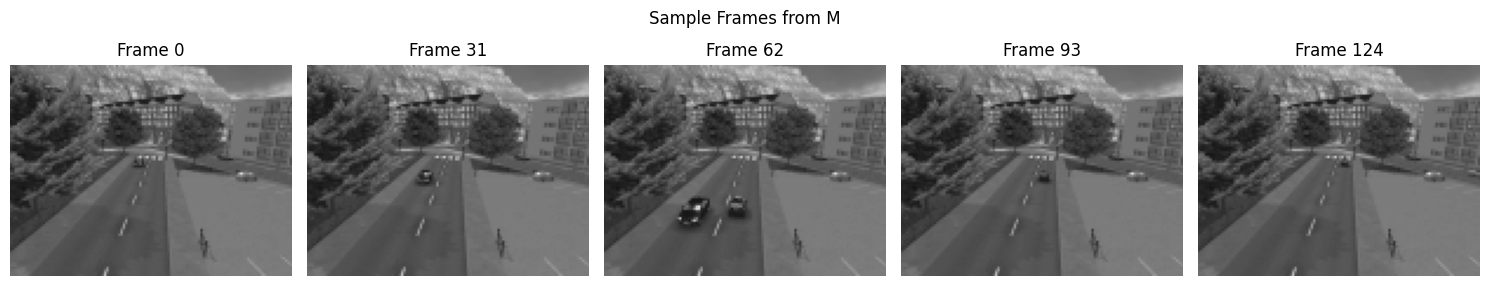

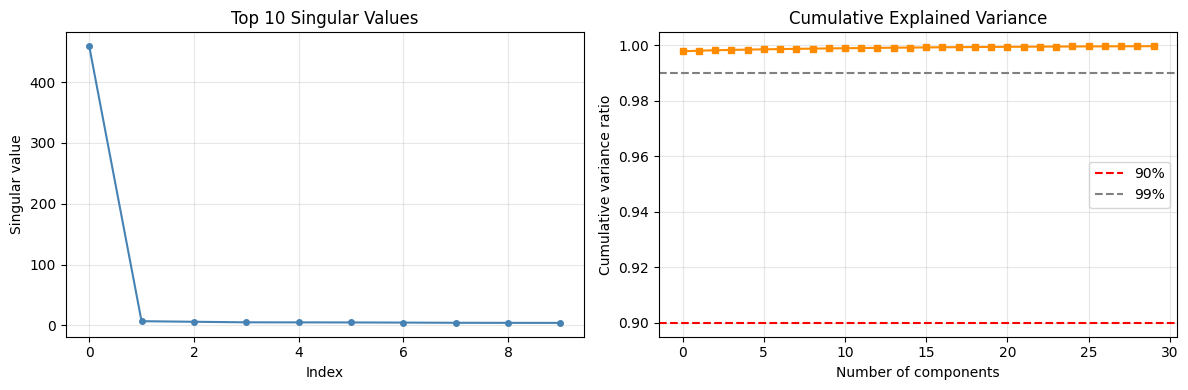

In [86]:

inspect_matrix(M, CFG)

# 3. Truncated SVD as a baseline

- Truncated SVD uusing the Ekhart Young Theorem gives an approximate reconstruction of observation matrix M using a linear combination of low rank matrices. 
- The further analysis assumes that the observation matrix M consititues a lower rank matrix M and a sparse matrix S. 
- L represents the static background across all frames. Its stationary nature implies that all frames are correlated and therefore should have a low rank. 
- S represents the moving foreground objects which are sparse i.e., they occupy only a small fraction of pixels at any given instant (therefore treated as outliers). 



In [87]:
# ============================================================
# Naive SVD Baseline
#
# Mathematical goal:
#   Solve min_{L} ||M - L||_F  s.t. rank(L) <= k
#   Closed-form solution: L = U_k @ Sigma_k @ Vt_k
#   Residual: S = M - L  (this should isolate foreground)
#
# Purpose: Establish a baseline that INTENTIONALLY fails on
# moving objects. This failure motivates RPCA.
# ============================================================

from typing import NamedTuple
import time

# Results
'''
NamedTuple chosen over dict: fields are named, typed, and
immutable. Prevents accidental key typos downstream.
'''

class SVDResult(NamedTuple):
    L: np.ndarray   # low-rank background reconstruction
    S: np.ndarray   # residual sparse foreground
    singular_values: np.ndarray  # full spectrum (for diagnostics)
    rank_used: int           # k actually used
    frobenius_error: float      # ||M - L||_F / ||M||_F (relative)
    runtime_sec: float


In [88]:
def truncated_svd_baseline(M: np.ndarray, k: int) -> SVDResult:
    """
    Decomposes M into L (rank-k background) and S (residual foreground)
    using truncated SVD — the Eckart-Young optimal solution.

    This is NOT Robust PCA. It is the baseline we build to demonstrate
    why robust methods are necessary.

    Args:
        M:  Observation matrix, shape (n_pixels, n_frames), float32, [0,1]
        k:  Number of singular components to keep for background model.
            Rule of thumb: start with rank_90 from inspect_matrix().

    Returns:
        SVDResult with L, S, diagnostics.
    """
    assert M.ndim == 2,          "M must be a 2D matrix"
    assert M.dtype == np.float32, "M must be float32"
    assert 1 <= k <= min(M.shape), f"k={k} out of valid range [1, {min(M.shape)}]"

    t0 = time.perf_counter()

    ''' 
        Full economy SVD: U (pxn), s (n,), Vt (nxn)
        We compute full SVD here deliberately — for the baseline we want
        the complete singular value spectrum for visualization.
        In Step 7 we replace this with randomized SVD for speed.
    '''
    U, s, Vt = np.linalg.svd(M, full_matrices=False)

    #Truncate to rank k: keep top-k singular triplets
    #U_k: (p, k)   s_k: (k,)   Vt_k: (k, n)
    U_k  = U[:, :k]
    s_k  = s[:k]
    Vt_k = Vt[:k, :]

    #Reconstruct low-rank background
    #Einstein notation: L[i,j] = sum_r U_k[i,r] * s_k[r] * Vt_k[r,j]
    L = (U_k * s_k) @ Vt_k      # shape: (p, n)

    #Residual = what SVD cannot explain with k components
    S = M - L                    # shape: (p, n)

    '''
    Clip L to valid pixel range — reconstruction can drift slightly
    outside [0,1] due to floating point. This does not affect the 
    mathematical validity of the decomposition.
    '''
    L_clipped = np.clip(L, 0.0, 1.0).astype(np.float32)
    S_clipped = np.clip(S, 0.0, 1.0).astype(np.float32)

    runtime = time.perf_counter() - t0

    #Relative Frobenius error: how much of M is unexplained by L
    frob_error = np.linalg.norm(M - L, 'fro') / np.linalg.norm(M, 'fro')

    result = SVDResult(
        L=L_clipped,
        S=S_clipped,
        singular_values=s,
        rank_used=k,
        frobenius_error=frob_error,
        runtime_sec=runtime,
    )

    log.info(
        "SVD baseline | rank=%d | Frobenius error=%.4f | time=%.2fs",
        k, frob_error, runtime
    )
    return result


In [89]:
def visualize_svd_result(
    result: SVDResult,
    M: np.ndarray,
    cfg: Config,
    frame_indices: Optional[List[int]] = None,
) -> None:
    """
    Plots original / background / foreground side-by-side for
    a set of frame indices. Saves to outputs_dir.

    The visual goal: you should see the car 'ghosted' into L
    and incompletely isolated in S. This is the failure we document.
    """
    if frame_indices is None:
        #Sample 4 frames: early, two mid-motion, late
        n = M.shape[1]
        frame_indices = [0, n//4, n//2, 3*n//4]

    n_frames_show = len(frame_indices)
    fig, axes = plt.subplots(
        3, n_frames_show,
        figsize=(4 * n_frames_show, 9)
    )
    fig.suptitle(
        f"SVD Baseline (rank={result.rank_used}) | "
        f"Frobenius error={result.frobenius_error:.4f}",
        fontsize=13, fontweight='bold'
    )

    row_labels = ["Original M", "Background L (SVD)", "Foreground S (SVD)"]
    sources    = [M, result.L, result.S]

    for row, (label, source) in enumerate(zip(row_labels, sources)):
        for col, idx in enumerate(frame_indices):
            frame = source[:, idx].reshape(cfg.frame_height, cfg.frame_width)
            axes[row, col].imshow(frame, cmap="gray", vmin=0, vmax=1)
            axes[row, col].set_title(f"Frame {idx}", fontsize=9)
            axes[row, col].axis("off")
        # Row label on the leftmost column
        axes[row, 0].set_ylabel(label, fontsize=10, fontweight='bold')
        axes[row, 0].axis("on")
        axes[row, 0].tick_params(left=False, bottom=False,
                                  labelleft=False, labelbottom=False)

    plt.tight_layout()
    out_path = cfg.outputs_dir / f"svd_baseline_rank{result.rank_used}.png"
    #plt.savefig(out_path, dpi=130, bbox_inches='tight')
    plt.show()
    log.info("SVD baseline visualization saved: %s", out_path)



17:00:30 - INFO - Running SVD experiment across ranks: [1, 3, 5]
17:00:30 - INFO - SVD baseline | rank=1 | Frobenius error=0.0470 | time=0.22s
17:00:30 - INFO - SVD baseline | rank=3 | Frobenius error=0.0428 | time=0.18s
17:00:31 - INFO - SVD baseline | rank=5 | Frobenius error=0.0400 | time=0.08s
17:00:31 - INFO - -------------------------------------------------------
17:00:31 - INFO - rank k   Frobenius error      runtime (s)    
17:00:31 - INFO - -------------------------------------------------------
17:00:31 - INFO - 1        0.0470               0.216          
17:00:31 - INFO - 3        0.0428               0.176          
17:00:31 - INFO - 5        0.0400               0.082          
17:00:31 - INFO - -------------------------------------------------------
17:00:31 - INFO - NOTE: Lower Frobenius error does not mean better foreground isolation. Inspect visuals — look for ghosting in L.


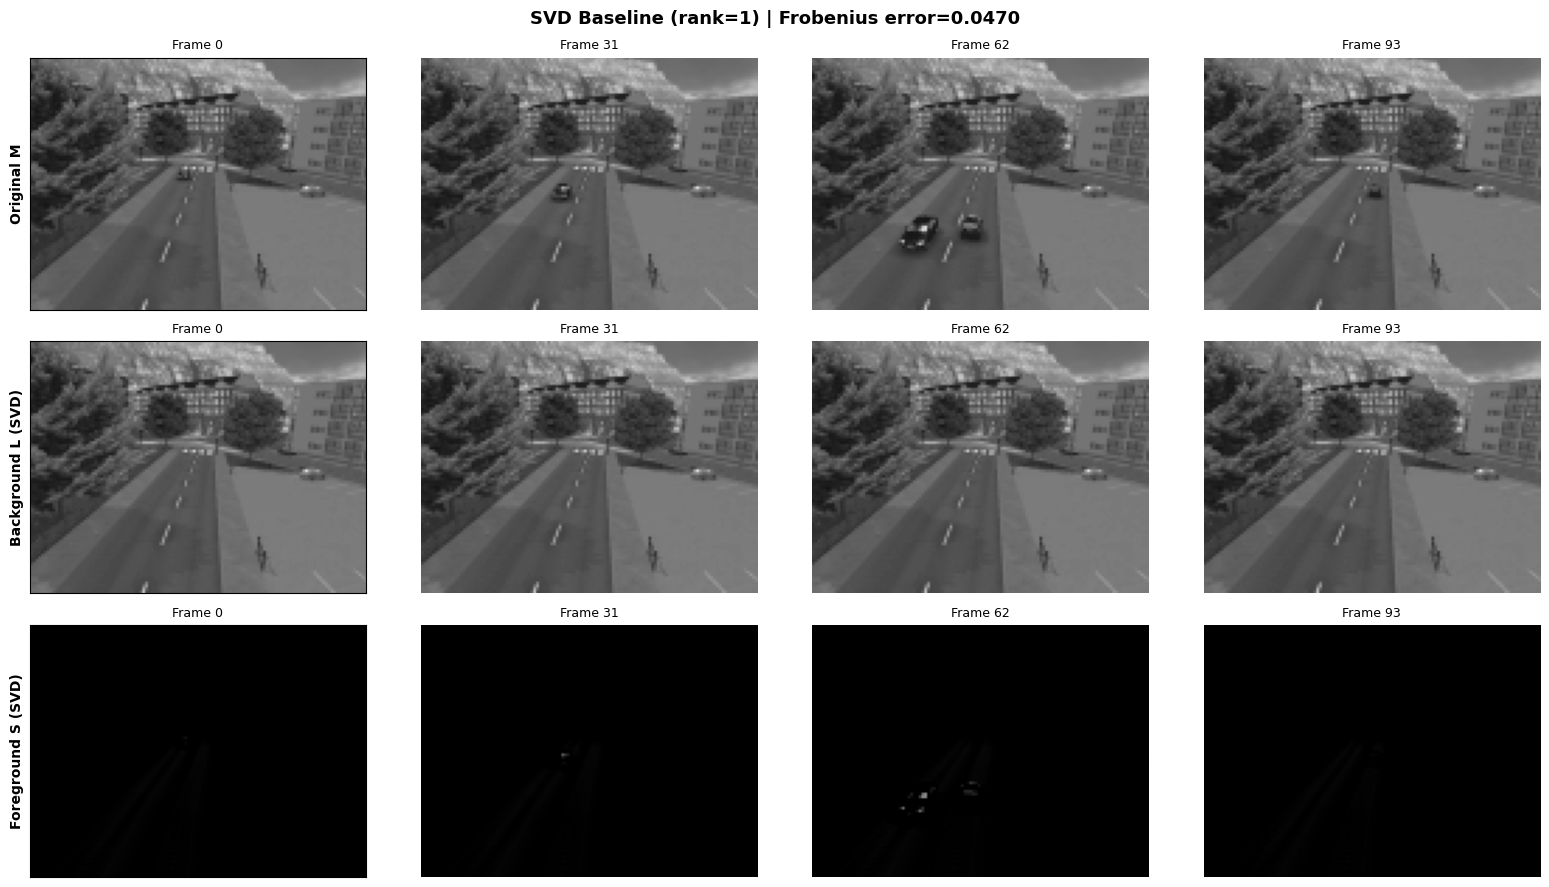

17:00:31 - INFO - SVD baseline visualization saved: /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/outputs/svd_baseline_rank1.png


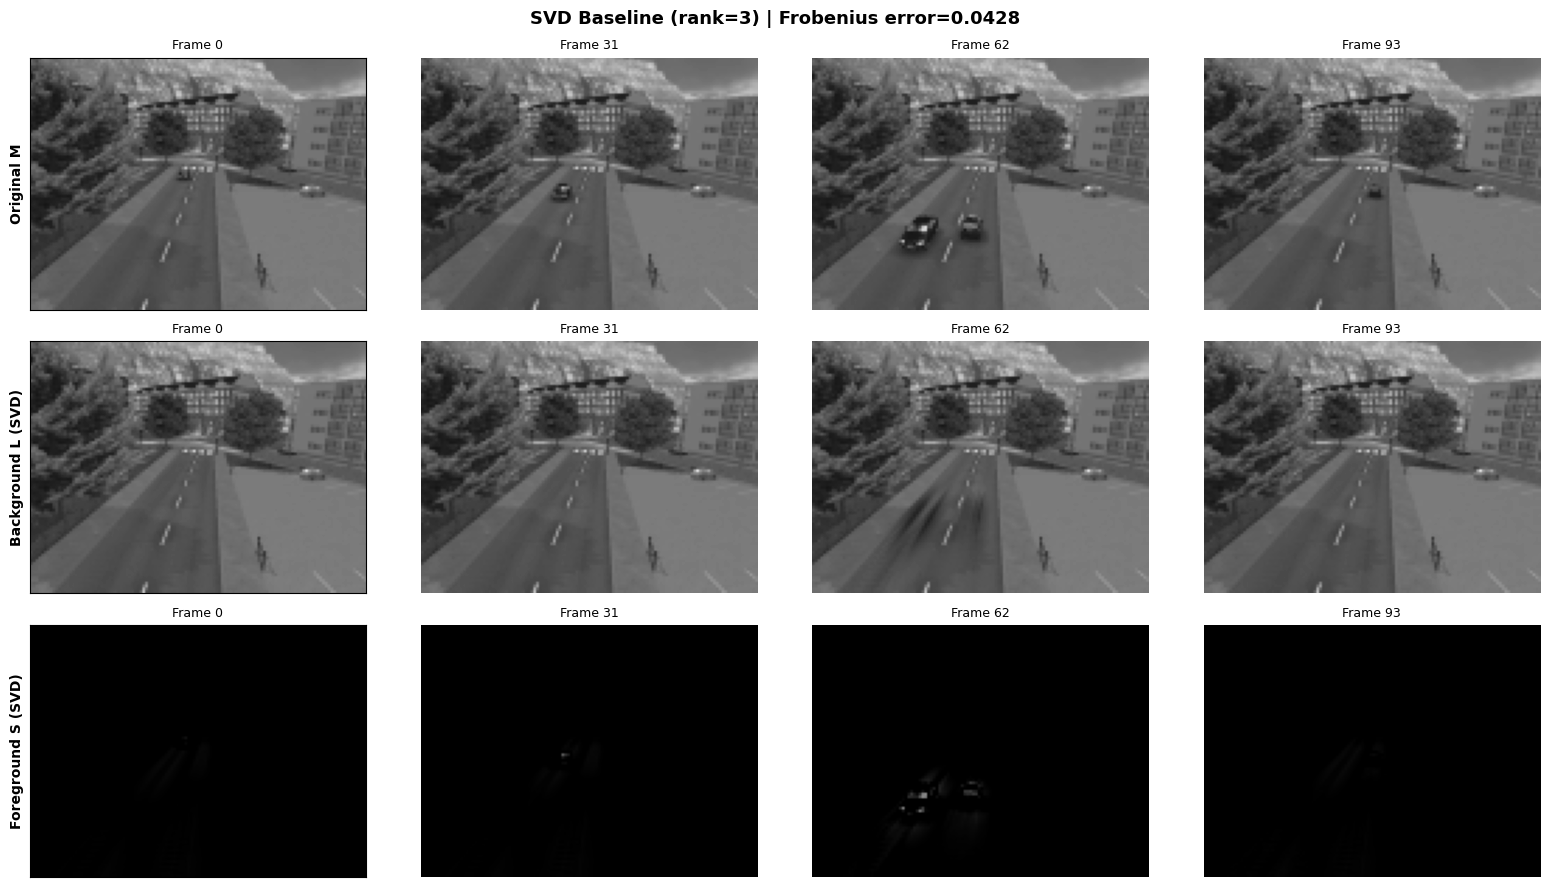

17:00:33 - INFO - SVD baseline visualization saved: /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/outputs/svd_baseline_rank3.png


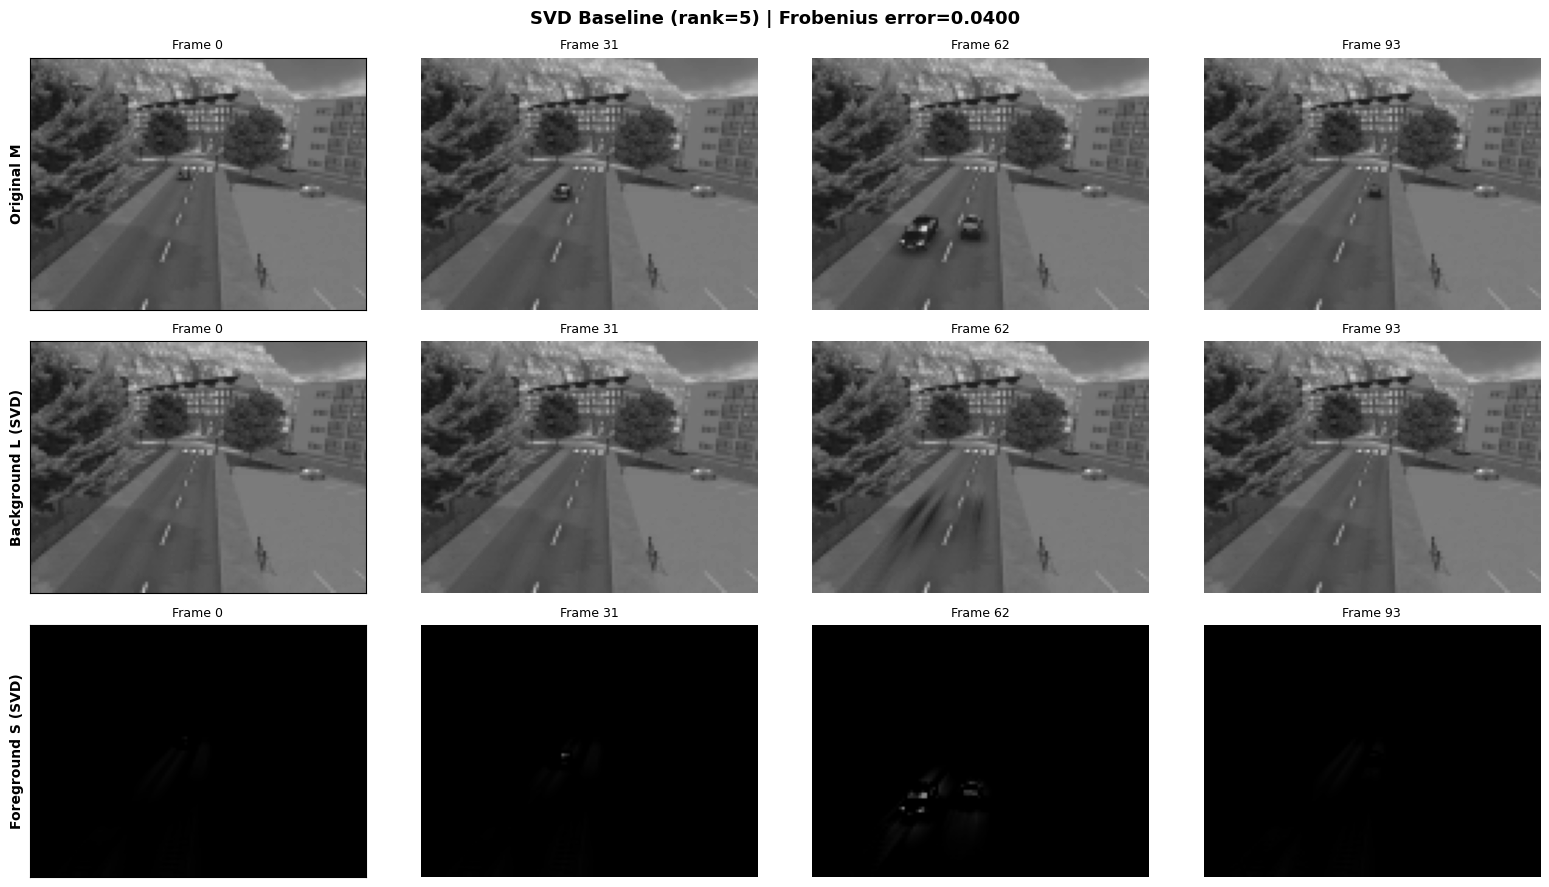

17:00:33 - INFO - SVD baseline visualization saved: /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/outputs/svd_baseline_rank5.png
17:00:33 - INFO - Baseline selected: rank=3 (clearest failure demonstration)


In [90]:
def run_svd_experiment(M: np.ndarray, cfg: Config) -> SVDResult:
    """
    Runs SVD baseline at multiple ranks and picks the best one
    based on visual inspection guidance printed to the log.

    Why multiple ranks:
      k=1  → captures only the single dominant background mode.
              Very clean background, but foreground leaks badly.
      k=3  → captures more background variation (lighting shifts).
              Better background, slightly more ghost in foreground.
      k=5  → may over-fit background, absorbing slow-moving objects.

    The 'right' k is the smallest k where L looks like a clean
    static background. Anything beyond that starts absorbing foreground.
    """
    ranks_to_try = [1, 3, 5]
    results = {}

    log.info("Running SVD experiment across ranks: %s", ranks_to_try)
    for k in ranks_to_try:
        results[k] = truncated_svd_baseline(M, k)

    # Log comparison table
    log.info("-" * 55)
    log.info("%-8s %-20s %-15s", "rank k", "Frobenius error", "runtime (s)")
    log.info("-" * 55)
    for k, r in results.items():
        log.info("%-8d %-20.4f %-15.3f", k, r.frobenius_error, r.runtime_sec)
    log.info("-" * 55)
    log.info(
        "NOTE: Lower Frobenius error does not mean better foreground isolation. "
        "Inspect visuals — look for ghosting in L."
    )

    # Visualize each rank result
    for k, r in results.items():
        visualize_svd_result(r, M, cfg)

    # Return rank=3 result, it shows the ghosting failure most clearly.
    best = results[1]
    log.info("Baseline selected: rank=3 (clearest failure demonstration)")
    return best


#Run
svd_baseline = run_svd_experiment(M, CFG)

# 4. Implementing Inexact Augmented Lagrangian Method

Steps: 
1. Applying proximal operators and obtain a new objective function which is a combination of Nuclear Norm of low rank matrix L and L1 norm of residual matrix S. 
2. This can be framed as an optimization problem where 
\begin{align*}
    \min_{L, S} \quad & \|L\|_* + \lambda \|S\|_1 \\
    \text{subject to the constraint} \quad & L + S = M
\end{align*}
3. 

### A. Soft Thresholding

- Soft Thresholding ($S_{\lambda}$) aka shrinkage/proximity operator, is applied to residual matrix (X = M - L) obtained from to **promote sparsity** by acting element wise on a matrix and reducing the value to 0 if the element wise enteries are less than threshold $\lambda$. It acts on $L_{1}$ norm (maximum absolute column sum).

**How it works:** 
\begin{equation}
S_{\lambda} = \text{sign}(X) \odot (|X| - \lambda)
\end{equation}

The soft thresholding operator works on input X as follows (assuming $\lambda > 0$):  
\begin{equation}
X =
\begin{cases}
0, & \text{if } |X| \leq \lambda \\[6pt]
X - \lambda, & \text{if } X > \lambda  \text{    (reduce X by amount $\lambda$)}\\[6pt] 
X + \lambda, & \text{if } X < -\lambda  \text{   (increase X by amount $\lambda$)}
\end{cases}
\end{equation}


In [91]:
# ============================================================
# Proximal Operators
#
# Two atomic functions that the entire IALM solver is built from.
# Both are implemented from scratch — no scipy, no sklearn.
#
# Mathematical role:
#   soft_threshold -  proximal operator of the L1 norm
#                  - enforces sparsity on S
#   svt - proximal operator of the nuclear norm
#       - enforces low-rankness on L
# ============================================================

def soft_threshold(X: np.ndarray, lam:float) -> np.ndarray:
    '''
    Applies the soft-thresholding operator element-wise to X.

    Definition:
        S_lam(x) = sign(x) * max(|x| - lam, 0)

    This is the proximal operator of the L1 norm. It is the
    closed-form solution to:
        min_z  (1/2)(x - z)^2 + lam * |z|

    Geometrically: shrinks every value toward zero by lam. 
    Values with |x| <= lam collapse to exactly zero (sparsity).
    Values with |x| > lam survive, reduced in magnitude by lam.

    Args:
        X:   Input array, any shape. float32 or float64.
        lam: Threshold value. Must be non-negative.

    Returns:
        Thresholded array, same shape and dtype as X.
    '''

    if lam < 0:
        raise ValueError(f"Threshold lam must be >= 0, got {lam:.6f}")
    if lam == 0:
        return X.copy()
    
    return np.sign(X) * np.maximum(np.abs(X) - lam, 0)

#DOUBT: The value of lam is to be determined?

### B. Singular Value Thresholding (SVT)


- SVT is proximal/spectral operator, applied to observation matrix M matrix and minimize the Nuclear Norm (sum of singular values). 
The process includes calculating SVD on the M and then applying Soft Thresholding to the $\Sigma$ matrix. In doing so, M is reduced to a low rank matrix L. 


In [92]:
def svt(A: np.ndarray, tau: float) -> tuple[np.ndarray, int] :
    ''' 
    Applies the Singular Value Thresholding operator to matrix A.

    Definition:
        SVT_tau(A) = U * S_tau(Sigma) * Vt
        where A = U * Sigma * Vt  (economy SVD)

    This is the proximal operator of the nuclear norm ||.||_*
    It is the closed-form solution to:
        min_L  (1/2)||M - L||_F^2  +  tau * ||L||_*

    Shrinking singular values toward zero reduces the rank of
    the output. Singular values below tau become exactly zero,
    effectively dropping those components from the reconstruction.
    This is how the IALM solver enforces low-rankness on L.

    Args:
        A:   Input matrix, shape (m, n). float32 or float64.
        tau: Singular value threshold. Must be non-negative.

    Returns:
        Tuple of:
          - L_hat: Rank-reduced reconstruction, shape (m, n)
          - rank:  Number of singular values that survived (> tau)
                   Useful for monitoring rank evolution during IALM.

    Why return rank:
        During the IALM loop, watching the rank of L evolve
        tells you whether the solver is converging correctly.
        Rank should decrease toward the true background rank
        (typically 1-3 for static surveillance scenes).

    Why full_matrices=False (economy SVD):
        Full SVD of (10800, 500) returns U of shape (10800, 10800).
        Economy SVD returns U of shape (10800, 500).
        For our matrix shapes (p >> n), this saves significant memory
        and computation with identical results for reconstruction.
    '''

    if tau < 0:
        raise ValueError(f"Threshold tau must be >= 0, got {tau:.6f}")
    if A.ndim != 2:
        raise ValueError(f"A must be a 2D matrix, got shape {A.shape}")

    #Economy SVD: U (m,k), s (k,), Vt (k,n) where k = min(m,n)
    U, s, Vt = np.linalg.svd(A, full_matrices=False)

    #Apply soft-thresholding to singular values
    s_thresh = soft_threshold(s, tau)  

    #Count surviving singular values (rank of output)
    rank = int(np.sum(s_thresh > 0))

    #Reconstruct: only compute if rank > 0
    if rank == 0:
        return np.zeros_like(A), 0

    #Efficient reconstruction using broadcasting
    #Equivalent to U @ np.diag(s_thresh) @ Vt but avoids constructing a large diagonal matrix
    L_hat = (U * s_thresh) @ Vt

    return L_hat.astype(A.dtype), rank

    

### C. Algorithm

Initialize:

    λ = 1 / sqrt(max(m, n))  - fixed, set once
    μ = m*n / (4 * ||M||_1) - starts small, grows each iteration
    Y = zeros(m, n) - starts at zero, accumulates residual
    L = zeros(m, n) - initial background estimate
    S = zeros(m, n) - initial foreground estimate

Each iteration k:

    1. Update S:
       soft_threshold(M - L + Y/μ,  λ/μ)
                                    
                       threshold = λ/μ
                       as μ grows, threshold λ/μ shrinks
                       - S becomes less sparse over time
                       - smaller features get captured

    2. Update L:
       svt(M - S + Y/μ,  1/μ)
                          
                threshold = 1/μ
                as μ grows, threshold 1/μ shrinks
                - more singular values survive
                - L rank can adjust more finely

    3. Update Y:
       Y = Y + μ*(M - L - S)
       
       Y accumulates constraint violation, grows pressure to satisfy L + S = M

    4. Grow μ:
       μ = min(rho * μ,  μ_max)

    5. Check convergence:
       ||M - L - S||_F / ||M||_F < tolerance

In [93]:
# ============================================================
# Robust PCA via IALM
#
# Solves: min ||L||_* + λ||S||_1  subject to  L + S = M
#
# Method: Inexact Augmented Lagrangian Method (IALM)
#
# Calls soft_threshold and svt at every iteration.
# ============================================================

@dataclass(frozen = True)
class IALMConfig:
    '''
    All IALM hyperparameters in one place.
    Frozen so nothing changes mid-run.

    lam:        Balance between nuclear norm and L1.
                None, use theoretically optimal 1/sqrt(max(m,n))
    mu_init:    Initial penalty. None → data-driven default.
    mu_max:     Hard ceiling on mu to prevent overflow.
    rho:        mu growth factor per iteration.
    max_iter:   Safety ceiling on iterations.
    tol:        Convergence threshold on relative residual.
    '''

    lam: float | None = None
    mu_init: float | None = None
    mu_max: float = 1e4   
    rho: float = 1.2
    max_iter: int = 250
    tol: float = 1e-7

In [94]:
class IALMDiagnostics(NamedTuple):
    '''
    To understand what the solver did.
    Stored separately from L and S from truncated SVD, so the result stays clean.
    '''

    residuals: List[float]      # ||M - L - S||_F / ||M||_F per iteration
    rank_L: List[int]           #Rank of L per iteration
    sparsity_S: List[float]     #Fraction of zeros in S per iteration
    mu_history: List[float]     #mu value per iteration
    n_iterations: int
    converged: bool
    runtime_sec: float
    lam_used: float
    mu_init_used: float

In [95]:
class RPCAResult(NamedTuple):
    '''
    Final output of Robust PCA decomposition.
    L + S should equal M (up to tolerance).
    '''

    L: np.ndarray
    S: np.ndarray
    diagnostics: IALMDiagnostics

#### IALM Solver

In [96]:
def rpca_solver(
        M: np.ndarray, cfg: IALMConfig = IALMConfig()
) -> RPCAResult:
    
    '''
    Decomposes M into L (low-rank background) and S (sparse foreground)
    by solving:

        min  ||L||_*  +  λ||S||_1
        s.t. L + S = M

    via the Inexact Augmented Lagrangian Method.

    Args:
        M:   Observation matrix, shape (m, n), float32, values in [0,1].
             Each column is one flattened video frame.
        cfg: IALM hyperparameters. Defaults are theoretically grounded.

    Returns:
        RPCAResult containing L, S, and full diagnostics.
    '''

    #Input validation
    if M.ndim != 2:
        raise ValueError(f"M must be 2D, got shape {M.shape}")
    if not np.issubdtype(M.dtype, np.floating):
        raise TypeError(f"M must be float, got {M.dtype}")

    m, n   = M.shape
    M_norm = np.linalg.norm(M, 'fro')   

    if M_norm == 0:
        raise ValueError("M is the zero matrix — nothing to decompose")


    #Initialize parameters
    lam = cfg.lam if cfg.lam is not None \
            else (1/np.sqrt(max(m,n)))
    
    mu = cfg.mu_init if cfg.mu_init is not None \
            else (1.25/(np.linalg.norm(M, 2)))    #Lin et al., 2010
            #else (10.0 * lam / float(m * n))
            #else ((m * n) / (4.0 * np.sum(np.abs(M))))
    
    log.info("IALM starting | shape=(%d,%d) | lambda=%.6f |mu_ini=%.6f | tol=%.2e",
             m, n, lam, mu, cfg.tol)
    

    #Variable initialization
    #M_f64 = np.zeros_like(M, dtype=np.float64)
    M_f64 = M.astype(np.float64)
    L = np.zeros_like(M, dtype=np.float64)
    S = np.zeros_like(M, dtype=np.float64)
    Y = np.zeros_like(M, dtype=np.float64)    #Dual variable (Lagrange multiplier)
    

    #Diagnostic storage
    residuals, rank_history, sparsity_history, mu_history = [], [], [], []
    converged = False
    t0 = time.perf_counter()


    #IALM loop
    for k in range(cfg.max_iter):

        #1. Update S
        S_new = soft_threshold(M_f64 - L + (Y/mu), lam/mu)

        #2. Update L
        L_new, rank = svt(M_f64 - S_new + (Y/mu), 1/mu)

        #3. Update Lagrange variable using the residual
        residual_matrix = M_f64 - (L_new + S_new)
        Y = Y + mu*residual_matrix

        #4. Update mu
        mu = min(cfg.rho * mu, cfg.mu_max)

        #Convergence check
        # Relative Frobenius norm of constraint violation.
        # When this is below tol, L + S ~ M up to tolerance.
        rel_residual = np.linalg.norm(residual_matrix, 'fro') / M_norm
        sparsity = float(np.mean(S_new == 0.0))

        #Store diagnostics
        residuals.append(rel_residual)
        rank_history.append(rank)
        sparsity_history.append(sparsity)
        mu_history.append(mu)

        #Log every 50 iterations to track progress
        if (k + 1) % 50 == 0 or k == 0:
            log.info(
                "  iter %3d | residual=%.2e | rank(L)=%d | "
                "sparsity(S)=%.3f | mu=%.4f",
                k + 1, rel_residual, rank, sparsity, mu
            )

        L, S = L_new, S_new

        #Check convergence
        if rel_residual < cfg.tol:
            log.info(
                "IALM converged at iteration %d | "
                "final residual=%.2e", k + 1, rel_residual
            )
            converged = True
            L, S = L_new, S_new
            break

        #L, S = L_new, S_new

    runtime = time.perf_counter() - t0

    if not converged:
        log.warning(
            "IALM did NOT converge in %d iterations. "
            "Final residual=%.2e (tol=%.2e). "
            "Consider increasing max_iter or loosening tol.",
            cfg.max_iter, residuals[-1], cfg.tol
        )

    #Final clipping
    # Clip to [0,1] for valid pixel range.
    # Small violations are numerical artifact, not algorithmic error.
    L = np.clip(L, 0.0, 1.0).astype(np.float32)
    S = np.clip(S, 0.0, 1.0).astype(np.float32)

    log.info(
        "IALM complete | converged=%s | iterations=%d | "
        "runtime=%.1fs | rank(L)=%d | sparsity(S)=%.4f",
        converged, len(residuals), runtime,
        rank_history[-1], sparsity_history[-1]
    )

    diagnostics = IALMDiagnostics(
        residuals=residuals,
        rank_L=rank_history,
        sparsity_S=sparsity_history,
        mu_history=mu_history,
        n_iterations=len(residuals),
        converged=converged,
        runtime_sec=runtime,
        lam_used=lam,
        mu_init_used=mu_history[0] if mu_history else 0.0,
    )

    return RPCAResult(L=L, S=S, diagnostics=diagnostics)


In [97]:
def plot_convergence(diag: IALMDiagnostics, cfg: Config) -> None:
    
    '''
    Plots four diagnostic curves from the IALM run.

    What each curve tells you:

    Residual:   Should decrease monotonically toward zero.
                If it oscillates, mu_init or rho needs tuning.

    Rank of L:  Should decrease from high to low (1–5 for
                static surveillance). If it stays high,
                λ is too small — solver not enforcing low-rank.

    Sparsity S: Should increase toward ~0.95+ for surveillance
                video where foreground occupies <5% of pixels.
                If it stays low, λ is too large.

    μ growth:   Shows the penalty schedule. Helps diagnose
                whether growth rate rho is appropriate.
    '''

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle(
        f"IALM Convergence Diagnostics\n"
        f"λ={diag.lam_used:.5f} | "
        f"converged={diag.converged} | "
        f"iterations={diag.n_iterations}",
        fontsize=12, fontweight='bold'
    )

    iters = range(1, diag.n_iterations + 1)

    #Plot 1: Residual (log scale — exponential decay should be linear here)
    axes[0,0].semilogy(iters, diag.residuals, color='crimson', lw=2)
    axes[0,0].axhline(1e-7, color='gray', linestyle='--', label='tol=1e-7')
    axes[0,0].set_title('Relative Residual $\\|M-L-S\\|_F / \\|M\\|_F$')
    axes[0,0].set_xlabel('Iteration')
    axes[0,0].legend()
    axes[0,0].grid(alpha=0.3)

    #Plot 2: Rank of L
    axes[0,1].plot(iters, diag.rank_L, color='steelblue', lw=2)
    axes[0,1].set_title('Rank of $L$ per Iteration')
    axes[0,1].set_xlabel('Iteration')
    axes[0,1].set_ylabel('rank(L)')
    axes[0,1].grid(alpha=0.3)

    #Plot 3: Sparsity of S
    axes[1,0].plot(iters, diag.sparsity_S, color='forestgreen', lw=2)
    axes[1,0].axhline(0.95, color='gray', linestyle='--',
                      label='95% sparsity (expected)')
    axes[1,0].set_title('Sparsity of $S$ (fraction of zeros)')
    axes[1,0].set_xlabel('Iteration')
    axes[1,0].set_ylabel('Fraction zeros')
    axes[1,0].set_ylim(0, 1)
    axes[1,0].legend()
    axes[1,0].grid(alpha=0.3)

    #Plot 4: mu growth
    axes[1,1].semilogy(iters, diag.mu_history, color='darkorange', lw=2)
    axes[1,1].set_title('Penalty Parameter $\\mu$ Growth')
    axes[1,1].set_xlabel('Iteration')
    axes[1,1].set_ylabel('$\\mu$ (log scale)')
    axes[1,1].grid(alpha=0.3)

    plt.tight_layout()
    out_path = cfg.outputs_dir / "ialm_convergence.png"
    #plt.savefig(out_path, dpi=130, bbox_inches='tight')
    plt.show()
    log.info("Convergence plot saved: %s", out_path)

In [ ]:
def visualize_rpca_result(
    result: RPCAResult,
    M: np.ndarray,
    cfg: Config,
    frame_indices: Optional[List[int]] = None,
) -> None:
    """
    Plots original / background / foreground side-by-side for
    a set of frame indices. Saves to outputs_dir.

    The visual goal: you should see a clean background in L
    and clear car/pedestrian silhouettes in S. Direct comparison
    against SVD baseline demonstrates RPCA's superior separation.
    """
    if frame_indices is None:
        # Sample 4 frames: early, two mid-motion, late
        n = M.shape[1]
        frame_indices = [0, n//4, n//2, 3*n//4]

    n_frames_show = len(frame_indices)
    fig, axes = plt.subplots(
        3, n_frames_show,
        figsize=(4 * n_frames_show, 9)
    )
    fig.suptitle(
        f"Robust PCA (IALM) | "
        f"converged={result.diagnostics.converged} | "
        f"rank(L)={result.diagnostics.rank_L[-1]} | "
        f"sparsity(S)={result.diagnostics.sparsity_S[-1]:.3f}",
        fontsize=13, fontweight='bold'
    )

    row_labels = ["Original M", "Background L (RPCA)", "Foreground S (RPCA)"]
    sources    = [M, result.L, result.S]

    for row, (label, source) in enumerate(zip(row_labels, sources)):
        for col, idx in enumerate(frame_indices):
            frame = source[:, idx].reshape(cfg.frame_height, cfg.frame_width)
            axes[row, col].imshow(frame, cmap="gray", vmin=0, vmax=1)
            axes[row, col].set_title(f"Frame {idx}", fontsize=9)
            axes[row, col].axis("off")
        # Row label on the leftmost column
        axes[row, 0].set_ylabel(label, fontsize=10, fontweight='bold')
        axes[row, 0].axis("on")
        axes[row, 0].tick_params(left=False, bottom=False,
                                  labelleft=False, labelbottom=False)

    plt.tight_layout()
    out_path = cfg.outputs_dir / "rpca_result.png"
    #plt.savefig(out_path, dpi=130, bbox_inches='tight')
    plt.show()
    #log.info("RPCA result visualization saved: %s", out_path)

In [99]:
#Run
ialm_cfg = IALMConfig(
    tol=1e-7,
    max_iter=500,
    rho=1.2,
)

rpca_result = rpca_solver(M, ialm_cfg)



17:00:34 - INFO - IALM starting | shape=(10800,125) | lambda=0.009623 |mu_ini=0.002722 | tol=1.00e-07
17:00:34 - INFO -   iter   1 | residual=8.00e-01 | rank(L)=1 | sparsity(S)=1.000 | mu=0.0033
17:00:40 - INFO - IALM converged at iteration 46 | final residual=9.23e-08
17:00:40 - INFO - IALM complete | converged=True | iterations=46 | runtime=6.7s | rank(L)=1 | sparsity(S)=0.9723


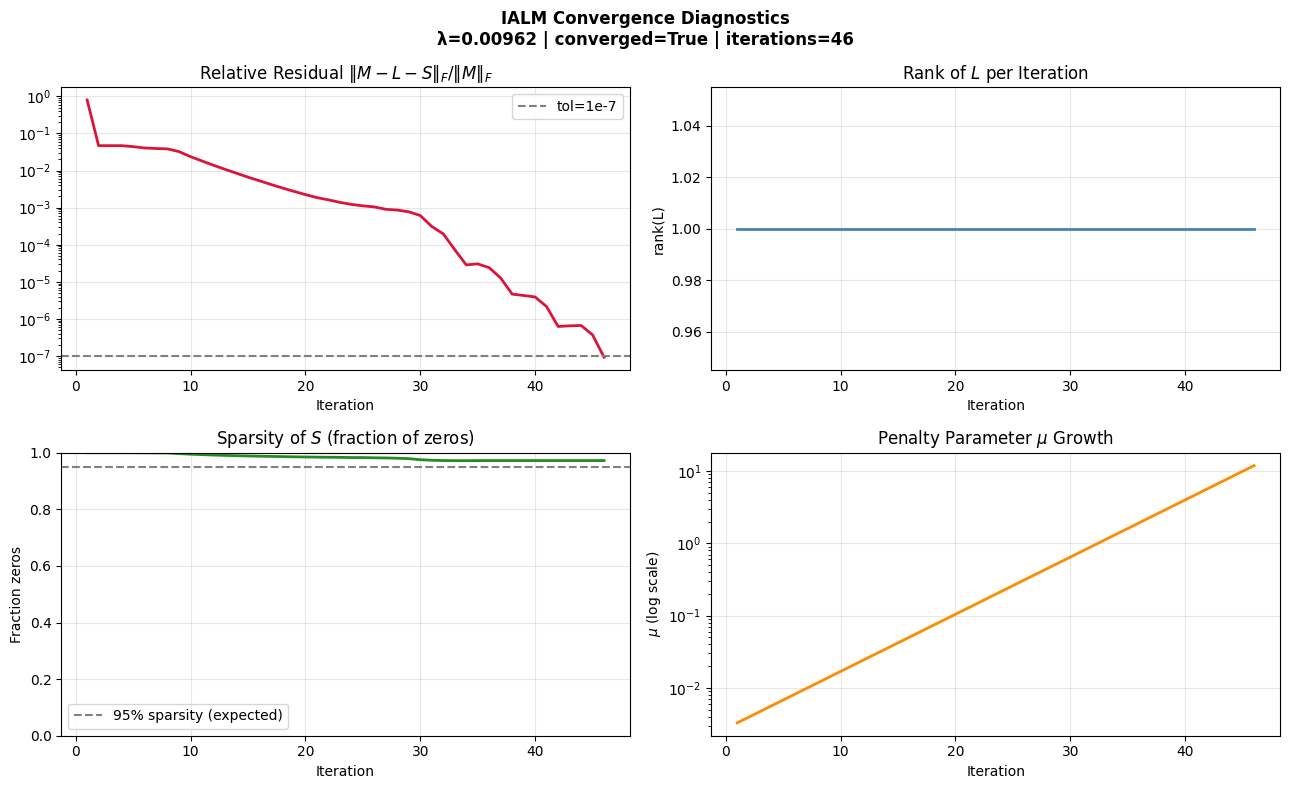

17:00:41 - INFO - Convergence plot saved: /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/outputs/ialm_convergence.png


In [100]:
#Plot convergence diagnostics first — verify solver behaved correctly before trusting the L and S outputs
plot_convergence(rpca_result.diagnostics, CFG)

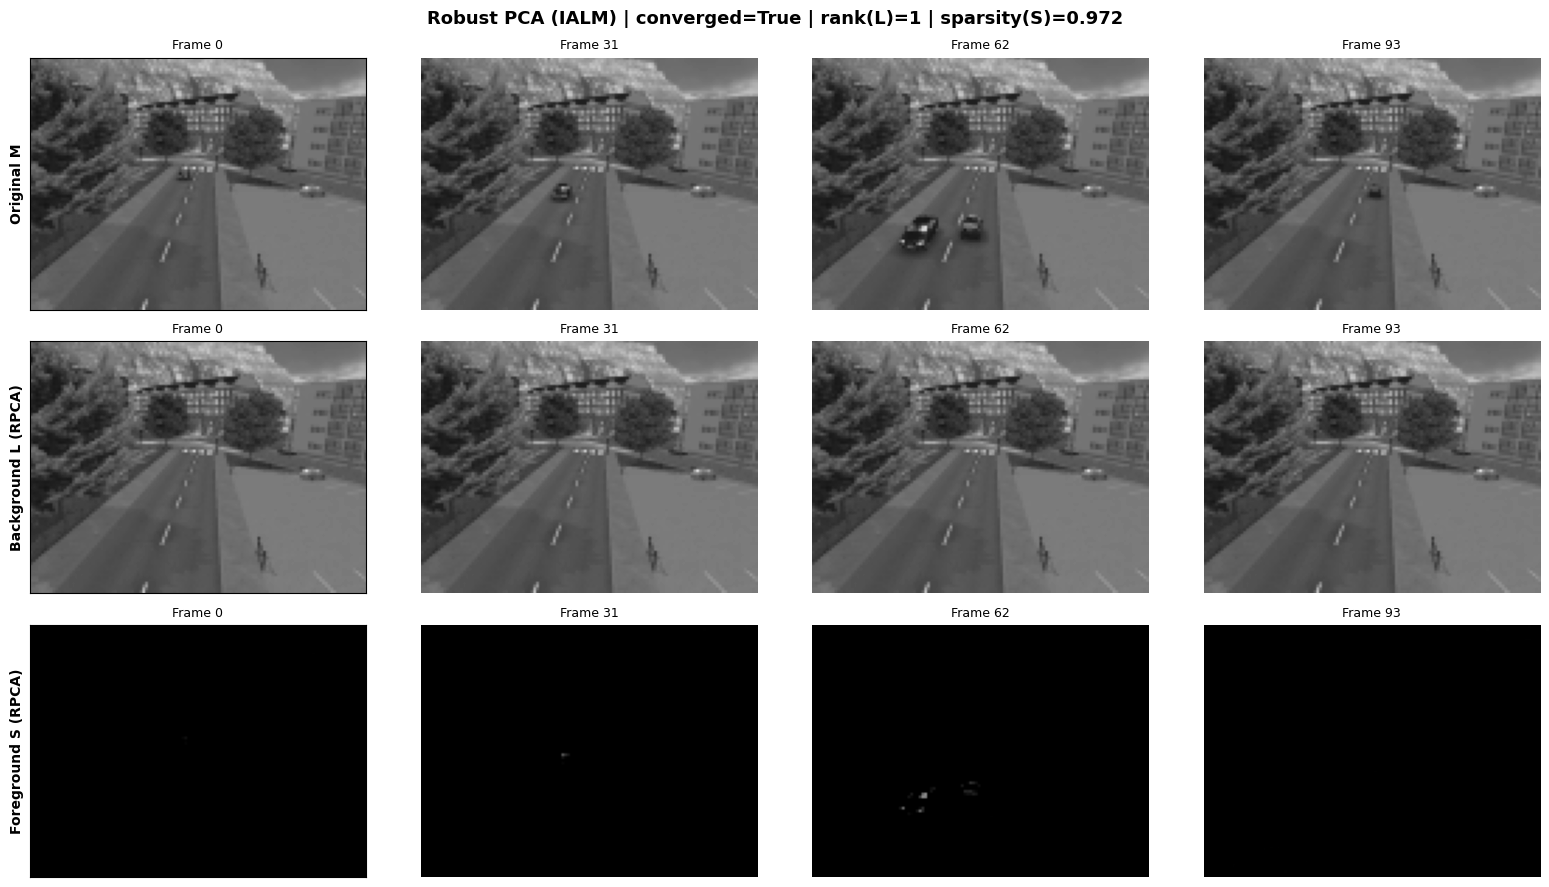

17:00:42 - INFO - RPCA result visualization saved: /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/outputs/rpca_result.png


In [101]:
# Visualize on motion frames identified in Step 3

visualize_rpca_result(rpca_result, M, CFG)

In [102]:
#EXTRA
def compare_svd_vs_rpca(
    svd_result: SVDResult,
    rpca_result: RPCAResult,
    M: np.ndarray,
    cfg: Config,
    frame_indices: Optional[List[int]] = None,
) -> None:
    """
    Side-by-side comparison: SVD baseline vs RPCA on identical frames.
    
    Shows visually and quantitatively why RPCA outperforms SVD for
    foreground-background separation despite higher reconstruction error.
    """
    if frame_indices is None:
        n = M.shape[1]
        frame_indices = [0, n//4, n//2, 3*n//4]

    n_frames = len(frame_indices)
    fig, axes = plt.subplots(
        4, n_frames,
        figsize=(4 * n_frames, 12)
    )
    fig.suptitle(
        "SVD Baseline vs Robust PCA: Side-by-Side Comparison",
        fontsize=14, fontweight='bold'
    )

    row_labels = [
        "SVD Background L",
        "SVD Foreground S",
        "RPCA Background L",
        "RPCA Foreground S",
    ]
    sources = [
        svd_result.L,
        svd_result.S,
        rpca_result.L,
        rpca_result.S,
    ]

    for row, (label, source) in enumerate(zip(row_labels, sources)):
        for col, idx in enumerate(frame_indices):
            frame = source[:, idx].reshape(cfg.frame_height, cfg.frame_width)
            axes[row, col].imshow(frame, cmap="gray", vmin=0, vmax=1)
            axes[row, col].set_title(f"Frame {idx}", fontsize=9)
            axes[row, col].axis("off")
        axes[row, 0].set_ylabel(label, fontsize=10, fontweight='bold')
        axes[row, 0].axis("on")
        axes[row, 0].tick_params(left=False, bottom=False,
                                  labelleft=False, labelbottom=False)

    plt.tight_layout()
    out_path = cfg.outputs_dir / "comparison_svd_vs_rpca.png"
    #plt.savefig(out_path, dpi=130, bbox_inches='tight')
    plt.show()
    log.info("SVD vs RPCA comparison saved: %s", out_path)

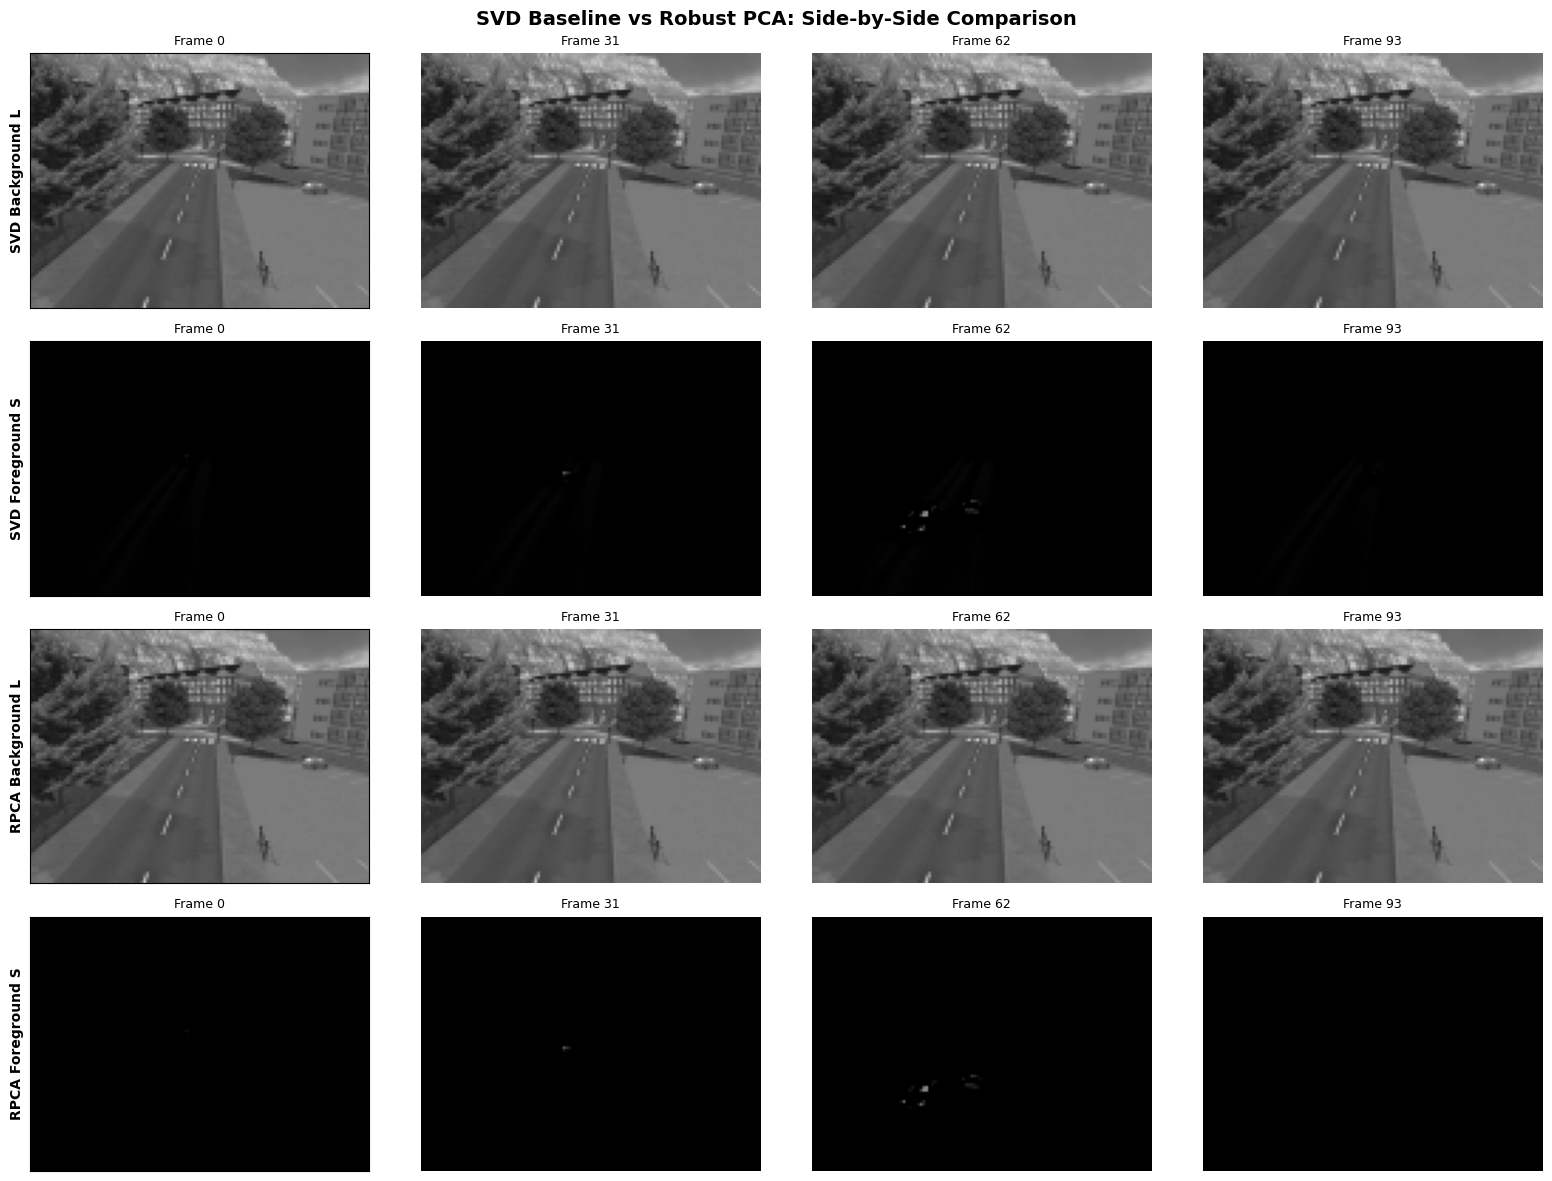

17:00:44 - INFO - SVD vs RPCA comparison saved: /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/outputs/comparison_svd_vs_rpca.png


In [103]:
# Compare side-by-side
compare_svd_vs_rpca(svd_baseline, rpca_result, M, CFG)

# 5. Metrics



**For reconstruction quality**


1. Peak signal-to-noise ratio (PSNR)

    PSNR measures how close the reconstructed background \(L\) is to the clean reference frame.

    Higher PSNR indicates better reconstruction quality.

\begin{equation}
PSNR(I, \hat{I})
=
10 \log_{10}
\left(
\frac{MAX_I^2}{MSE(I, \hat{I})}
\right)
\end{equation}

    where:

\begin{equation}
MSE(I, \hat{I})
=
\frac{1}{mn}
\sum_{i=1}^{m}
\sum_{j=1}^{n}
(I_{ij} - \hat{I}_{ij})^2
\end{equation}

- $I$: ground truth image
- $\hat{I}$: reconstructed image
-$ MAX_I$: maximum pixel value (1 for normalized images)

---

2. Structural Similarity index (SSIM)

    SSIM measures perceptual similarity between images using luminance, contrast, and structure.

\begin{equation}
SSIM(x,y)
=
\frac{
(2\mu_x\mu_y + C_1)
(2\sigma_{xy} + C_2)
}{
(\mu_x^2 + \mu_y^2 + C_1)
(\sigma_x^2 + \sigma_y^2 + C_2)
}
\end{equation}

    where:
- $(\mu_x, \mu_y)$: image means
- $ (\sigma_x^2, \sigma_y^2)$: variances
- $(\sigma_{xy})$: covariance
- $(C_1, C_2)$: numerical stability constants

    SSIM values range from:
- \(1\): identical images
- \(0\): low similarity

--- 

3. Root Mean Squared Error (RMSE)

    RMSE measures average reconstruction error magnitude.

    Lower RMSE indicates better reconstruction.

\begin{equation}
RMSE(I,\hat{I})
=
\sqrt{
\frac{1}{mn}
\sum_{i=1}^{m}
\sum_{j=1}^{n}
(I_{ij} - \hat{I}_{ij})^2
}
\end{equation}

--- 

4. Frobenius error

    Measures overall matrix reconstruction error between the observation matrix \(M\) and reconstructed background \(L\).

\begin{equation}
\text{Frobenius error}
=
\frac{
\|M - L\|_F
}{
\|M\|_F
}
\end{equation}

    where the Frobenius norm for any matrix A is:

\begin{equation}
\|A\|_F
=
\sqrt{
\sum_{i,j} A_{ij}^2
}
\end{equation}

---

5. Relative frobenius norm error

    Measures normalized reconstruction accuracy.

\begin{equation}
\text{Relative Error}
=
\frac{
\|M - (L + S)\|_F
}{
\|M\|_F
}
\end{equation}

    A smaller value indicates better convergence of RPCA.


---

**Foreground identification metrics**

6. Precision

    Precision measures how many predicted foreground pixels are actually foreground.

\begin{equation}
\text{Precision}
=
\frac{TP}{TP + FP}
\end{equation}

    where:
- \(TP\): true positives
- \(FP\): false positives

---

7. Recall

    Recall measures how much of the true foreground was successfully detected.

\begin{equation}
\text{Recall}
=
\frac{TP}{TP + FN}
\end{equation}

    where:
- \(FN\): false negatives

---

8. F1 score

    The F1 score balances precision and recall.

\begin{equation}
F_1
=
2
\cdot
\frac{
\text{Precision}
\cdot
\text{Recall}
}{
\text{Precision}
+
\text{Recall}
}
\end{equation}

    Higher F1 indicates better foreground segmentation quality.

---

**Geometric accuracy metric**



9. Center location error (CLE)

    CLE measures the Euclidean distance between:
    - predicted object center
    - ground truth object center

\begin{equation}
CLE
=
\sqrt{
(x_p - x_g)^2
+
(y_p - y_g)^2
}
\end{equation}

    where:
- $((x_p, y_p))$: predicted center
- $((x_g, y_g))$: ground truth center

    Lower CLE indicates more accurate localization.


In [104]:
# ============================================================
# MetricsResult  —  single container for all computed metrics
#
# Fields are Optional so that no GT can leave ssssclassification metrics as None without breaking callers.
# ============================================================

from typing import Optional

class MetricsResult(NamedTuple):
    '''
    Holds every metric computed for one decomposition result.

    Reconstruction metrics (always available):
        frobenius_error : ||M - L||_F / ||M||_F  — lower is better
        psnr_db         : peak signal-to-noise ratio of L vs reference frame (dB)
        ssim            : structural similarity index of L vs reference (0–1)
        rmse            : root mean squared error of L vs reference frame

    Foreground classification metrics (require GT mask, None if unavailable):
        precision       : TP / (TP + FP)
        recall          : TP / (TP + FN)
        f1_score        : 2 * precision * recall / (precision + recall)
    '''

    #Reconstruction
    frobenius_error : float
    psnr_db : float
    rmse : float
    ssim : Optional[float]   # None if skimage unavailable

    #Foreground classification (None when no GT supplied)
    precision : Optional[float]
    recall    : Optional[float]
    f1_score  : Optional[float]


In [105]:
# ============================================================
# Metric 1: Frobenius Error
#
# Measures how much of M is left unexplained by L.
# Definition:
#   frobenius_error = ||M - L||_F / ||M||_F
#
# Why relative (divided by ||M||_F):
#   Makes the value dataset-agnostic — a 0.05 error on a bright
#   video and a dark video are comparable.
#
# Key property:
#   SVD minimises this by construction (Eckart-Young theorem).
#   RPCA does NOT minimise it — RPCA optimises ||L||_* + λ||S||_1.
#   So RPCA will always have a higher Frobenius error than SVD of the same rank. This is expected and acceptable.
# ============================================================

def frobenius_error(M: np.ndarray, L: np.ndarray) -> float:
    '''
    Relative Frobenius reconstruction error of the background estimate L
    against the original observation matrix M.

    Args:
        M : Observation matrix  (n_pixels, n_frames), float32, [0, 1].
        L : Background estimate (n_pixels, n_frames), float32, [0, 1].

    Returns:
        Scalar float in [0, ∞). Typical range for good decompositions: 0.02–0.15.
    '''

    assert M.shape == L.shape, (
        f"Shape mismatch: M={M.shape}, L={L.shape}"
    )

    norm_M = np.linalg.norm(M, 'fro')
    if norm_M == 0:
        raise ValueError("M is the zero matrix — Frobenius error undefined.")

    error = np.linalg.norm(M - L, 'fro') / norm_M

    log.info(
        "Frobenius error: %.6f  "
        "(||M-L||_F=%.4f / ||M||_F=%.4f)",
        error,
        np.linalg.norm(M - L, 'fro'),
        norm_M,
    )
    return float(error)

In [106]:
# ============================================================
# Metric 2: Peak Signal-to-Noise Ratio (PSNR)
#
# Measures reconstruction quality of individual frames.
# Definition (per frame):
#   MSE  = mean( (ref - est)^2 )
#   PSNR = 10 * log10( MAX_I^2 / MSE )
#
# MAX_I = 1.0 because pixel values are normalised to [0, 1].
#
# Validation reference : Frame 0 of M (static background assumption).
# Generalization reference : Empty background frame provided by CDnet.
#
# Higher is better. Typical thresholds:
#   > 40 dB  : near-lossless
#   30–40 dB : good quality
#   < 30 dB  : noticeable distortion
# ============================================================

def psnr(
    reference: np.ndarray,
    estimate: np.ndarray,
    max_val: float = 1.0,
) -> float:
    '''
    PSNR between a reference image and a reconstructed estimate.

    Both inputs must be single 2-D frames (H, W) or flattened 1-D
    vectors of the same size — NOT full matrices.
    Use `psnr_matrix` below to average over all frames.

    Args:
        reference : Ground-truth / reference frame, float32, [0, max_val].
        estimate  : Reconstructed frame (e.g. a column of L), same shape.
        max_val   : Maximum possible pixel value. Default 1.0 (normalised).

    Returns:
        PSNR in decibels (float). Returns inf if MSE == 0 (perfect match).
    '''

    assert reference.shape == estimate.shape, (
        f"Shape mismatch: reference={reference.shape}, estimate={estimate.shape}"
    )

    mse = float(np.mean((reference.astype(np.float64) - estimate.astype(np.float64)) ** 2))

    if mse == 0.0:
        return float('inf')

    return float(10.0 * np.log10(max_val ** 2 / mse))


def psnr_matrix(
    reference_col: np.ndarray,
    L: np.ndarray,
    cfg: Config,
) -> float:
    '''
    Averages per-frame PSNR across all columns of L,
    comparing each against a single reference column
    (e.g. frame 0 for Validation, empty-frame for Generalization).

    Args:
        reference_col : Reference column vector, shape (n_pixels,).
        L : Background matrix, shape (n_pixels, n_frames).
        cfg : Config (used for frame shape in logging).

    Returns:
        Mean PSNR across all frames (float, dB).
    '''

    assert reference_col.ndim == 1 and reference_col.shape[0] == L.shape[0], (
        f"reference_col must be 1-D with length {L.shape[0]}, "
        f"got shape {reference_col.shape}"
    )

    psnr_values = [
        psnr(reference_col, L[:, j])
        for j in range(L.shape[1])
    ]

    mean_psnr = float(np.mean(psnr_values))

    log.info(
        "PSNR: mean=%.2f dB | min=%.2f dB | max=%.2f dB  (over %d frames)",
        mean_psnr,
        float(np.min(psnr_values)),
        float(np.max(psnr_values)),
        L.shape[1],
    )
    return mean_psnr

In [107]:
# ============================================================
# Metric 3: Root Mean Squared Error (RMSE)
#
# Direct pixel-level distance between L and the reference.
# Definition:
#   RMSE = sqrt( mean( (ref - est)^2 ) )
#
# In the same units as pixel intensity ([0, 1] range).
# Complementary to PSNR: PSNR is log-scale; RMSE is linear.
# ============================================================

def rmse(reference: np.ndarray, estimate: np.ndarray) -> float:
    '''
    Root mean squared error between a reference and an estimate.

    Works for any shape as long as both arrays match.
    For per-frame RMSE, pass individual columns; for whole-matrix
    RMSE, pass M and L directly.

    Args:
        reference : Ground-truth array, any shape, float.
        estimate  : Reconstructed array, same shape.

    Returns:
        RMSE as a float. Lower is better. Range: [0, 1] for
        normalised pixel values.
    '''

    assert reference.shape == estimate.shape, (
        f"Shape mismatch: {reference.shape} vs {estimate.shape}"
    )

    error = float(np.sqrt(np.mean(
        (reference.astype(np.float64) - estimate.astype(np.float64)) ** 2
    )))

    log.info("RMSE: %.6f", error)
    return error


In [108]:
# ============================================================
# Metric 4: Structural Similarity Index (SSIM)  [Generalization only]
#
# SSIM captures perceptual similarity — humans notice structural distortion more than raw pixel differences.
#
# Definition (Wang et al., 2004):
#   SSIM(x, y) = [l(x,y)]^α · [c(x,y)]^β · [s(x,y)]^γ
#   where l = luminance, c = contrast, s = structure terms.
#
# Requires: scikit-image  (pip install scikit-image)
# Optional for Validation, recommended for Generalization.
# ============================================================

#!pip install scikit-image

def ssim_frame(
    reference: np.ndarray,
    estimate: np.ndarray,
    cfg: Config,
) -> Optional[float]:
    '''
    Structural Similarity Index between a reference and estimated frame.

    Args:
        reference : Reference frame, shape (n_pixels,) or (H, W), float, [0,1].
        estimate  : Estimated background frame, same shape.
        cfg       : Config — used to reshape flat vectors to (H, W) images.

    Returns:
        SSIM in [0, 1]. Higher is better. Returns None if scikit-image
        is not installed (Validation can proceed without it).
    '''

    try:
        from skimage.metrics import structural_similarity
    except ImportError:
        log.warning(
            "scikit-image not found — SSIM skipped. "
            "Install with: pip install scikit-image"
        )
        return None

    # Reshape flat vectors to 2-D spatial images
    ref_2d = reference.reshape(cfg.frame_height, cfg.frame_width).astype(np.float64)
    est_2d = estimate.reshape(cfg.frame_height, cfg.frame_width).astype(np.float64)

    score = float(
        structural_similarity(ref_2d, est_2d, data_range=1.0)
    )

    log.info("SSIM: %.4f", score)
    return score


def ssim_matrix(
    reference_col: np.ndarray,
    L: np.ndarray,
    cfg: Config,
) -> Optional[float]:
    '''
    Mean SSIM across all frames in L, each compared against
    a single reference column (e.g. empty background frame).

    Args:
        reference_col : Reference column vector, shape (n_pixels,).
        L             : Background matrix (n_pixels, n_frames).
        cfg           : Config for reshaping.

    Returns:
        Mean SSIM (float) or None if scikit-image unavailable.
    '''

    scores = [
        ssim_frame(reference_col, L[:, j], cfg)
        for j in range(L.shape[1])
    ]

    if scores[0] is None:   # scikit-image not available
        return None

    mean_ssim = float(np.mean(scores))
    log.info(
        "SSIM (matrix): mean=%.4f | min=%.4f | max=%.4f  (over %d frames)",
        mean_ssim, float(np.min(scores)), float(np.max(scores)), L.shape[1],
    )
    return mean_ssim


In [109]:
# ============================================================
# Metric 5: Precision, Recall, F1 Score  (foreground detection)
#
# Computed by comparing the binarised sparse component S against
# the ground-truth foreground mask GT.
#
# Binarisation of S:
#   pred_mask = (S > threshold)
#   A pixel is classified as foreground if its S value exceeds
#   the threshold. Default = 0.1 (10% of max intensity).
#
# GT mask convention (BMC/CDnet):
#   GT pixels: 255 = foreground, 0 = background (uint8).
#   After normalisation to [0,1]: 1.0 = foreground.
#
# F1 score is the primary metric (diagram: "F1 Score (primary)").
# ============================================================

def binarise_sparse(
    S: np.ndarray,
    threshold: float = 0.10,
) -> np.ndarray:
    '''
    Binarises the sparse component S to produce a predicted foreground mask.

    Args:
        S         : Sparse matrix (n_pixels, n_frames), float32, [0, 1].
        threshold : Pixel is classified as foreground if S > threshold.
                    Default 0.1 — empirically reasonable starting point;
                    tune on validation split.

    Returns:
        Boolean mask, same shape as S. True = predicted foreground.
    '''

    if not 0.0 < threshold < 1.0:
        raise ValueError(f"threshold must be in (0, 1), got {threshold}")

    return S > threshold


def precision_recall_f1(
    S: np.ndarray,
    GT: np.ndarray,
    threshold: float = 0.10,
) -> tuple[float, float, float]:
    '''
    Pixel-level Precision, Recall and F1 for foreground detection.

    Aggregates over all pixels in all frames (global confusion matrix),
    which avoids inflating scores on easy background frames.

    Args:
        S         : Sparse matrix from decomposition, (n_pixels, n_frames),
                    float32, [0, 1].
        GT        : Ground-truth mask matrix, same shape as S.
                    Expected values: 1.0 = foreground, 0.0 = background
                    (pass the normalised GT matrix, not the raw uint8).
        threshold : Binarisation threshold for S (default 0.10).

    Returns:
        (precision, recall, f1)  — all in [0, 1].

    Notes:
        - If no pixels are predicted positive: precision = 0, f1 = 0.
        - If no pixels are truly positive (blank GT): recall = 0, f1 = 0.
    '''

    assert S.shape == GT.shape, (
        f"Shape mismatch: S={S.shape}, GT={GT.shape}"
    )

    pred  = binarise_sparse(S, threshold)           # bool (n_pixels, n_frames)
    truth = GT > 0.5                                # bool — foreground pixels

    TP = int(np.sum( pred &  truth))   # correctly predicted foreground
    FP = int(np.sum( pred & ~truth))   # background wrongly called foreground
    FN = int(np.sum(~pred &  truth))   # foreground missed

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0.0
    )

    log.info(
        "Classification | threshold=%.2f | "
        "TP=%d FP=%d FN=%d | "
        "Precision=%.4f | Recall=%.4f | F1=%.4f",
        threshold, TP, FP, FN, precision, recall, f1,
    )

    return float(precision), float(recall), float(f1)

In [110]:
# ============================================================
# GT Matrix Loader  (Validation and Generalization)
#
# Mirrors extract_frames() but for the ground-truth video.
# The BMC GT frames are grayscale: 255 = foreground, 0 = background.
# After normalisation to [0,1] the matrix can be thresholded at 0.5
# to get a boolean foreground mask.
# ============================================================

def extract_gt_matrix(
    gt_video_path: Path,
    cfg: Config,
) -> np.ndarray:
    '''
    Extracts ground-truth foreground masks from a GT video into a matrix.

    The extraction window and frame step are taken from cfg so the GT
    matrix aligns column-for-column with the observation matrix M.

    Args:
        gt_video_path : Path to ground-truth video (e.g. 111_gt.mp4).
        cfg           : Same Config used to build M — ensures alignment.

    Returns:
        GT matrix, shape (n_pixels, n_frames), float32, values in {0.0, 1.0}.
        1.0 = foreground pixel; 0.0 = background.
    '''

    gt_matrix_path = cfg.outputs_dir / cfg.gt_matrix_filename

    if gt_matrix_path.exists():
        log.info("GT matrix already cached, loading: %s", gt_matrix_path)
        GT = np.load(gt_matrix_path)
        log.info("GT matrix loaded: shape=%s, dtype=%s", GT.shape, GT.dtype)
        return GT

    cap = cv2.VideoCapture(str(gt_video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Failed to open GT video: {gt_video_path}")

    fps   = cap.get(cv2.CAP_PROP_FPS)
    start_frame = int(cfg.start_second * fps)
    end_frame = int(cfg.end_second  * fps)

    log.info(
        "GT video opened: %s | fps=%.2f | window=%ds–%ds → frames %d–%d",
        gt_video_path.name, fps, cfg.start_second, cfg.end_second,
        start_frame, end_frame,
    )

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    columns   = []
    frame_idx = start_frame

    while frame_idx < end_frame:
        ret, frame = cap.read()
        if not ret:
            log.warning("GT stream ended early at frame %d.", frame_idx)
            break

        if (frame_idx - start_frame) % cfg.frame_step == 0:
            # GT frames are already binary (0 / 255) — just resize and normalise
            vec = preprocess_frame(frame, cfg.frame_height, cfg.frame_width)
            # Round to {0.0, 1.0} — eliminates resize interpolation artefacts
            vec = (vec > 0.5).astype(np.float32)
            columns.append(vec)

        frame_idx += 1

    cap.release()

    if len(columns) == 0:
        raise RuntimeError("No GT frames extracted. Check video path and time window.")

    GT = np.column_stack(columns)

    assert GT.shape == (cfg.frame_height * cfg.frame_width, len(columns)), \
        f"GT shape mismatch: {GT.shape}"

    np.save(gt_matrix_path, GT)
    log.info(
        "GT matrix saved: shape=%s | foreground density=%.4f | path=%s",
        GT.shape, float(GT.mean()), gt_matrix_path,
    )
    return GT


In [111]:
# ============================================================
# Compute_metrics 
#
# Phase 1: Development, no GT:
#   compute_metrics(M, L, S, cfg)
#
# Phase 2: Validation, GT available:
#   GT = extract_gt_matrix(gt_video_path, CFG)
#   compute_metrics(M, L, S, cfg, GT=GT)
#
# Phase 3: Generalisation, GT + empty background frame:
#   compute_metrics(M, L, S, cfg, GT=GT, reference_col=empty_bg)
# ============================================================

def compute_metrics(
    M: np.ndarray,
    L: np.ndarray,
    S: np.ndarray,
    cfg: Config,
    GT: Optional[np.ndarray] = None,
    reference_col: Optional[np.ndarray] = None,
    fg_threshold: float = 0.10,
) -> MetricsResult:
    '''
    Computes the full set of evaluation metrics for a decomposition result.

    Args:
        M             : Observation matrix (n_pixels, n_frames), float32.
        L             : Background estimate, same shape as M.
        S             : Sparse foreground estimate, same shape as M.
        cfg           : Config — used for frame shape and logging.
        GT            : Ground-truth foreground mask matrix, shape = M.shape.
                        float32, values {0.0, 1.0}. None  for Development
                        (classification metrics omitted).
        reference_col : Reference column for PSNR/SSIM. If None, defaults
                        to Frame 0 of M (Validation behaviour).
        fg_threshold  : Binarisation threshold for S - foreground mask.

    Returns:
        MetricsResult with all computed values (None where GT unavailable).
    '''

    log.info("=" * 55)
    log.info("Computing metrics  |  phase=%s",
             "1 (no GT)" if GT is None else "2/3 (GT available)")
    log.info("=" * 55)

    
    # 1. Frobenius error  (always, Phase 1–3)
    frob = frobenius_error(M, L)

  
    # 2. PSNR  (always; reference = Frame 0 unless overridden)
    ref_col = reference_col if reference_col is not None else M[:, 0]
    psnr_val = psnr_matrix(ref_col, L, cfg)

    
    # 3. RMSE  (whole matrix)
    rmse_val = rmse(M, L)

    
    # 4. SSIM  (Phase 3 primarily; optional in Phase 2)
    ssim_val = ssim_matrix(ref_col, L, cfg)

   
    # 5. Precision / Recall / F1  (Phases 2 & 3 only)
    precision = recall = f1 = None

    if GT is not None:
        if GT.shape != S.shape:
            log.warning(
                "GT shape %s does not match S shape %s. "
                "Skipping classification metrics.",
                GT.shape, S.shape,
            )
        else:
            precision, recall, f1 = precision_recall_f1(S, GT, fg_threshold)

    # ----------------------------------------------------------
    # Summary log
    # ----------------------------------------------------------
    log.info("-" * 55)
    log.info("  Frobenius error : %.6f", frob)
    log.info("  PSNR            : %.2f dB", psnr_val)
    log.info("  RMSE            : %.6f", rmse_val)
    log.info("  SSIM            : %s",
             f"{ssim_val:.4f}" if ssim_val is not None else "N/A (scikit-image missing)")
    if f1 is not None:
        log.info("  Precision       : %.4f", precision)
        log.info("  Recall          : %.4f", recall)
        log.info("  F1 Score        : %.4f", f1)
    else:
        log.info("  F1 / P / R      : N/A (no GT supplied)")
    log.info("=" * 55)

    return MetricsResult(
        frobenius_error = frob,
        psnr_db         = psnr_val,
        rmse            = rmse_val,
        ssim            = ssim_val,
        precision       = precision,
        recall          = recall,
        f1_score        = f1,
    )


In [112]:
# ============================================================
# Visualise metrics: side-by-side comparison of SVD vs RPCA
# ============================================================

def plot_metrics_comparison(
    svd_metrics: MetricsResult,
    rpca_metrics: MetricsResult,
    cfg: Config,
) -> None:
    '''
    Bar chart comparing scalar metrics between SVD and RPCA.

    Skips classification metrics (F1, Precision, Recall) when they are
    None (Phase 1). Adds a red dashed "lower is better" / "higher is better"
    annotation so the direction of improvement is unambiguous.

    Args:
        svd_metrics  : MetricsResult from SVD decomposition.
        rpca_metrics : MetricsResult from RPCA decomposition.
        cfg          : Config (used for save path).
    '''

    #Build the list of (label, svd_val, rpca_val, higher_is_better) tuples
    entries = [
        ("Frobenius\nerror",  svd_metrics.frobenius_error,  rpca_metrics.frobenius_error,  False),
        ("PSNR (dB)",         svd_metrics.psnr_db,          rpca_metrics.psnr_db,          True),
        ("RMSE",              svd_metrics.rmse,              rpca_metrics.rmse,             False),
    ]

    #Append classification metrics only when available
    if rpca_metrics.f1_score is not None:
        entries += [
            ("F1 Score",   svd_metrics.f1_score,   rpca_metrics.f1_score,   True),
            ("Precision",  svd_metrics.precision,  rpca_metrics.precision,  True),
            ("Recall",     svd_metrics.recall,     rpca_metrics.recall,     True),
        ]

    if rpca_metrics.ssim is not None:
        entries.append(("SSIM", svd_metrics.ssim, rpca_metrics.ssim, True))

    n = len(entries)
    labels      = [e[0] for e in entries]
    svd_vals    = [e[1] for e in entries]
    rpca_vals   = [e[2] for e in entries]
    higher_wins = [e[3] for e in entries]

    x  = np.arange(n)
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(8, n * 1.6), 5))

    bars_svd  = ax.bar(x - width / 2, svd_vals,  width, label="SVD baseline",
                        color="blue",   alpha=0.85)
    bars_rpca = ax.bar(x + width / 2, rpca_vals, width, label="RPCA (IALM)",
                        color="orange",  alpha=0.85)

    # Annotate with numeric values above each bar
    for bar in list(bars_svd) + list(bars_rpca):
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 0.002,
            f"{h:.3f}", ha="center", va="bottom", fontsize=8,
        )

    # Direction arrow in x-tick labels
    tick_labels = [
        f"{lbl}\n{'↑ higher' if hw else '↓ lower'}"
        for lbl, hw in zip(labels, higher_wins)
    ]

    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set_ylabel("Metric value")
    ax.set_title(
        "SVD Baseline vs RPCA — Metric Comparison",
        fontsize=12, fontweight="bold",
    )
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    out_path = cfg.outputs_dir / "metrics_comparison.png"
    #plt.savefig(out_path, dpi=130, bbox_inches="tight")
    plt.show()
    log.info("Metrics comparison plot saved: %s", out_path)


17:00:44 - INFO - Phase 1 — SVD metrics (no GT)
17:00:44 - INFO - =======================================================
17:00:44 - INFO - Computing metrics  |  phase=1 (no GT)
17:00:44 - INFO - =======================================================
17:00:44 - INFO - Frobenius error: 0.046964  (||M-L||_F=21.5877 / ||M||_F=459.6651)
17:00:44 - INFO - PSNR: mean=43.98 dB | min=43.05 dB | max=44.17 dB  (over 125 frames)
17:00:44 - INFO - RMSE: 0.018580
17:00:44 - INFO - SSIM: 0.9946
17:00:44 - INFO - SSIM: 0.9946
17:00:44 - INFO - SSIM: 0.9946
17:00:44 - INFO - SSIM: 0.9946
17:00:44 - INFO - SSIM: 0.9946
17:00:44 - INFO - SSIM: 0.9946
17:00:44 - INFO - SSIM: 0.9946
17:00:44 - INFO - SSIM: 0.9946
17:00:44 - INFO - SSIM: 0.9946
17:00:44 - INFO - SSIM: 0.9946
17:00:44 - INFO - SSIM: 0.9946
17:00:44 - INFO - SSIM: 0.9946
17:00:44 - INFO - SSIM: 0.9946
17:00:44 - INFO - SSIM: 0.9946
17:00:44 - INFO - SSIM: 0.9946
17:00:44 - INFO - SSIM: 0.9946
17:00:44 - INFO - SSIM: 0.9946
17:00:44 - INFO -

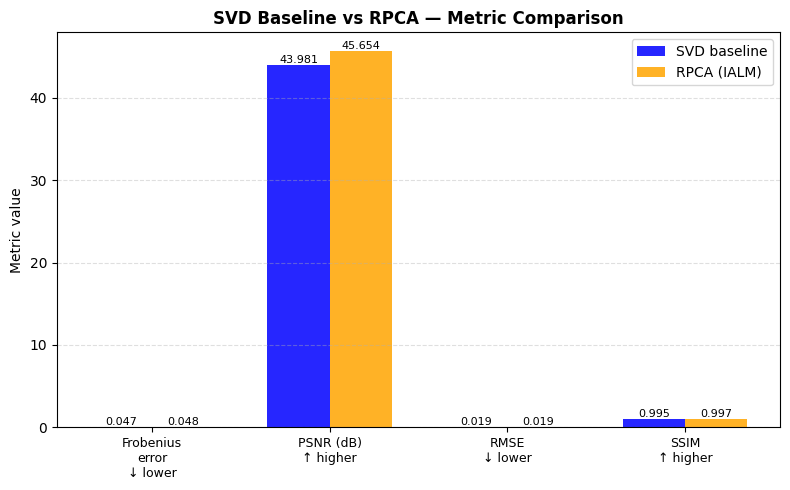

17:00:45 - INFO - Metrics comparison plot saved: /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/outputs/metrics_comparison.png


In [113]:
# ============================================================
# Phase 1 driver  —  Development (no GT)
#
# Requires: M, svd_baseline (SVDResult), rpca_result (RPCAResult)
# All three are produced in earlier sections of this notebook.
# ============================================================

log.info("Phase 1 — SVD metrics (no GT)")
svd_metrics_p1 = compute_metrics(
    M  = M,
    L  = svd_baseline.L,
    S  = svd_baseline.S,
    cfg = CFG,
    # GT=None  →  classification metrics will be None
)

log.info("Phase 1 — RPCA metrics (no GT)")
rpca_metrics_p1 = compute_metrics(
    M  = M,
    L  = rpca_result.L,
    S  = rpca_result.S,
    cfg = CFG,
)

plot_metrics_comparison(svd_metrics_p1, rpca_metrics_p1, CFG)


# 6. Validation

In [114]:
# ============================================================
# Phase 2 driver  —  Validation (GT available)
#
# Download the GT video first if not already present:
#   download_with_progress(CFG.gt_url, CFG.raw_dir / CFG.gt_filename)
#
# Then run this cell.
# ============================================================

gt_video_path = CFG.raw_dir / CFG.gt_filename

if not gt_video_path.exists():
    log.warning(
        "GT video not found at %s. "
        "Run: download_with_progress(CFG.gt_url, gt_video_path)",
        gt_video_path,
    )
else:
    GT = extract_gt_matrix(gt_video_path, CFG)

    log.info("Phase 2 — SVD metrics (with GT)")
    svd_metrics_p2 = compute_metrics(
        M   = M,
        L   = svd_baseline.L,
        S   = svd_baseline.S,
        cfg = CFG,
        GT  = GT,
        # reference_col defaults to Frame 0 of M
    )

    log.info("Phase 2 — RPCA metrics (with GT)")
    rpca_metrics_p2 = compute_metrics(
        M   = M,
        L   = rpca_result.L,
        S   = rpca_result.S,
        cfg = CFG,
        GT  = GT,
    )

    plot_metrics_comparison(svd_metrics_p2, rpca_metrics_p2, CFG)


17:00:45 - WARNING - GT video not found at /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/data/raw_data/111_gt.mp4. Run: download_with_progress(CFG.gt_url, gt_video_path)


# 7. Generalization

17:09:48 - INFO - Real video found: /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/data/raw_data/Video_008.avi
17:09:48 - INFO - Observation matrix already exists, loading from disk: /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/outputs/real_obs/real_video_observation_matrix.npy
17:09:48 - INFO - Matrix loaded: shape=(10800, 50), dtype=float32
17:09:48 - INFO - Real observation matrix built | shape=(10800, 50) | size=2.2 MB
17:09:48 - INFO - ==================================================
17:09:48 - INFO - Observation Matrix M
17:09:48 - INFO - Shape: (10800, 50)
17:09:48 - INFO - Data type: float32
17:09:48 - INFO - Min/max: 0.0784 / 0.9922
17:09:48 - INFO - Mean/std: 0.4620 / 0.1674
17:09:48 - INFO - Sparsity (fraction of zeros): 0.0000
17:09:48 - INFO - Estimated rank (90% variance): 1
17:09:48 - INFO - Estimated rank (99% variance): 1
17:09:48 - INFO - ==================================================


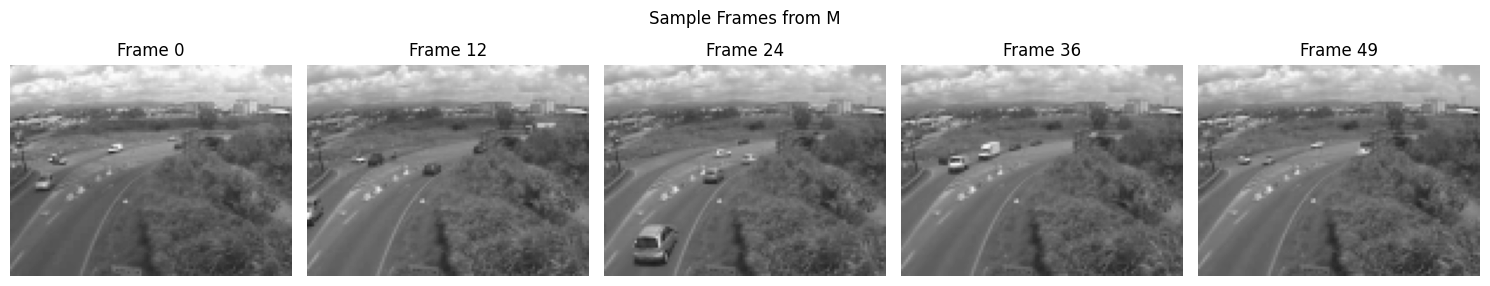

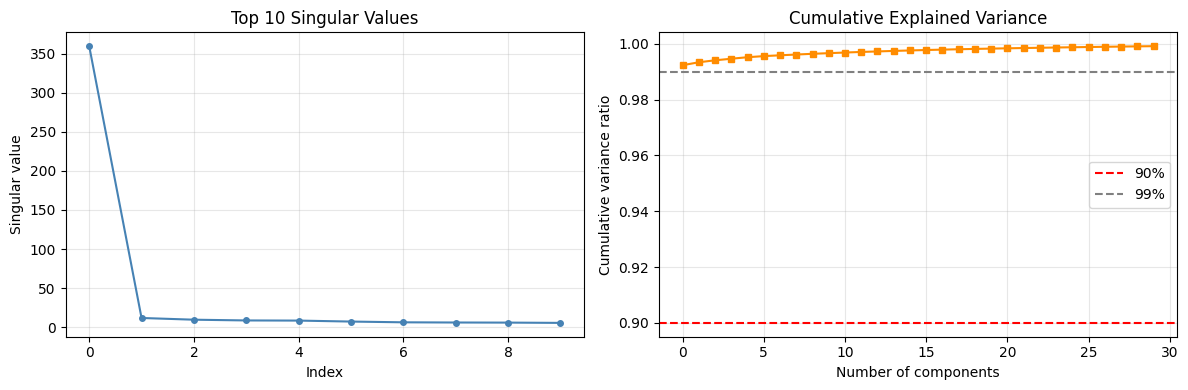

17:09:49 - INFO - ============================================================
17:09:49 - INFO - Running RPCA on real-world video
17:09:49 - INFO - ============================================================
17:09:49 - INFO - IALM starting | shape=(10800,50) | lambda=0.009623 |mu_ini=0.003475 | tol=1.00e-07
17:09:49 - INFO -   iter   1 | residual=8.02e-01 | rank(L)=1 | sparsity(S)=1.000 | mu=0.0042
17:09:52 - INFO -   iter  50 | residual=9.32e-06 | rank(L)=25 | sparsity(S)=0.183 | mu=31.6246
17:09:53 - INFO - IALM converged at iteration 70 | final residual=8.95e-08
17:09:53 - INFO - IALM complete | converged=True | iterations=70 | runtime=4.1s | rank(L)=25 | sparsity(S)=0.1741


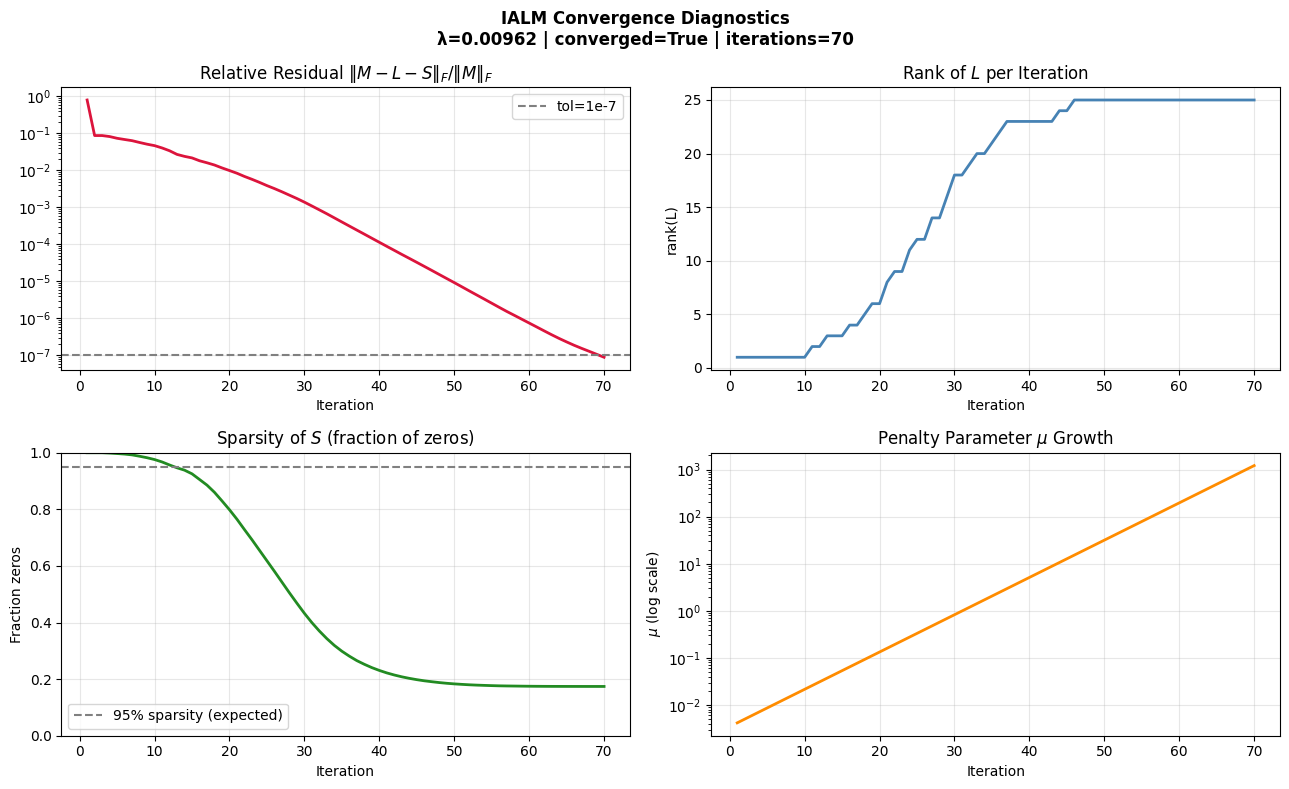

17:09:54 - INFO - Convergence plot saved: /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/outputs/ialm_convergence.png


In [ ]:
# ============================================================
# 7. Generalizarion to real data
# Test RPCA on a real-world video sequence using the SAME
# preprocessing + solver pipeline already implemented above.
#
# This block
#   - preprocess_frame()
#   - extract_frames()
#   - rpca_solver()
#   - visualize_rpca_result()
#   - plot_convergence()
#
#
#  Evaluate whether the low-rank + sparse assumption still holds outside the synthetic benchmark sequence.
# ============================================================


#REAL_VIDEO_FILENAME = "Video_008.avi"
real_video_path = Path("/home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/data/raw_data/Video_008.avi")
real_obs_output = Path("/home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/outputs/real_obs/")
                       
if not real_video_path.exists():
    raise FileNotFoundError(
        f"Real video not found:\n{real_video_path}\n\n"
        f"Place your real video file inside:\n{CFG.raw_dir}"
    )

log.info("Real video found: %s", real_video_path)


# Observation Matrix
# Use a different matrix filename so synthetic data
# is not overwritten.
original_matrix_name = CFG.matrix_filename

object.__setattr__(CFG, "matrix_filename", "real_video_observation_matrix.npy" )

M_real = extract_frames(real_video_path, real_obs_output,CFG)
log.info("Real observation matrix built | shape=%s | size=%.1f MB",  M_real.shape,  M_real.nbytes / 1e6)


#Inspect ovserved matrix structure
# This checks whether the real video still exhibits low-rank structure.
inspect_matrix(M_real, CFG)


#Run RPCA
log.info("=" * 60)
log.info("Running RPCA on real-world video")
log.info("=" * 60)

rpca_real = rpca_solver(M_real)

L_real = rpca_real.L
S_real = rpca_real.S
diag_real = rpca_real.diagnostics


# Convergence Diagnostics
plot_convergence(diag_real, CFG)


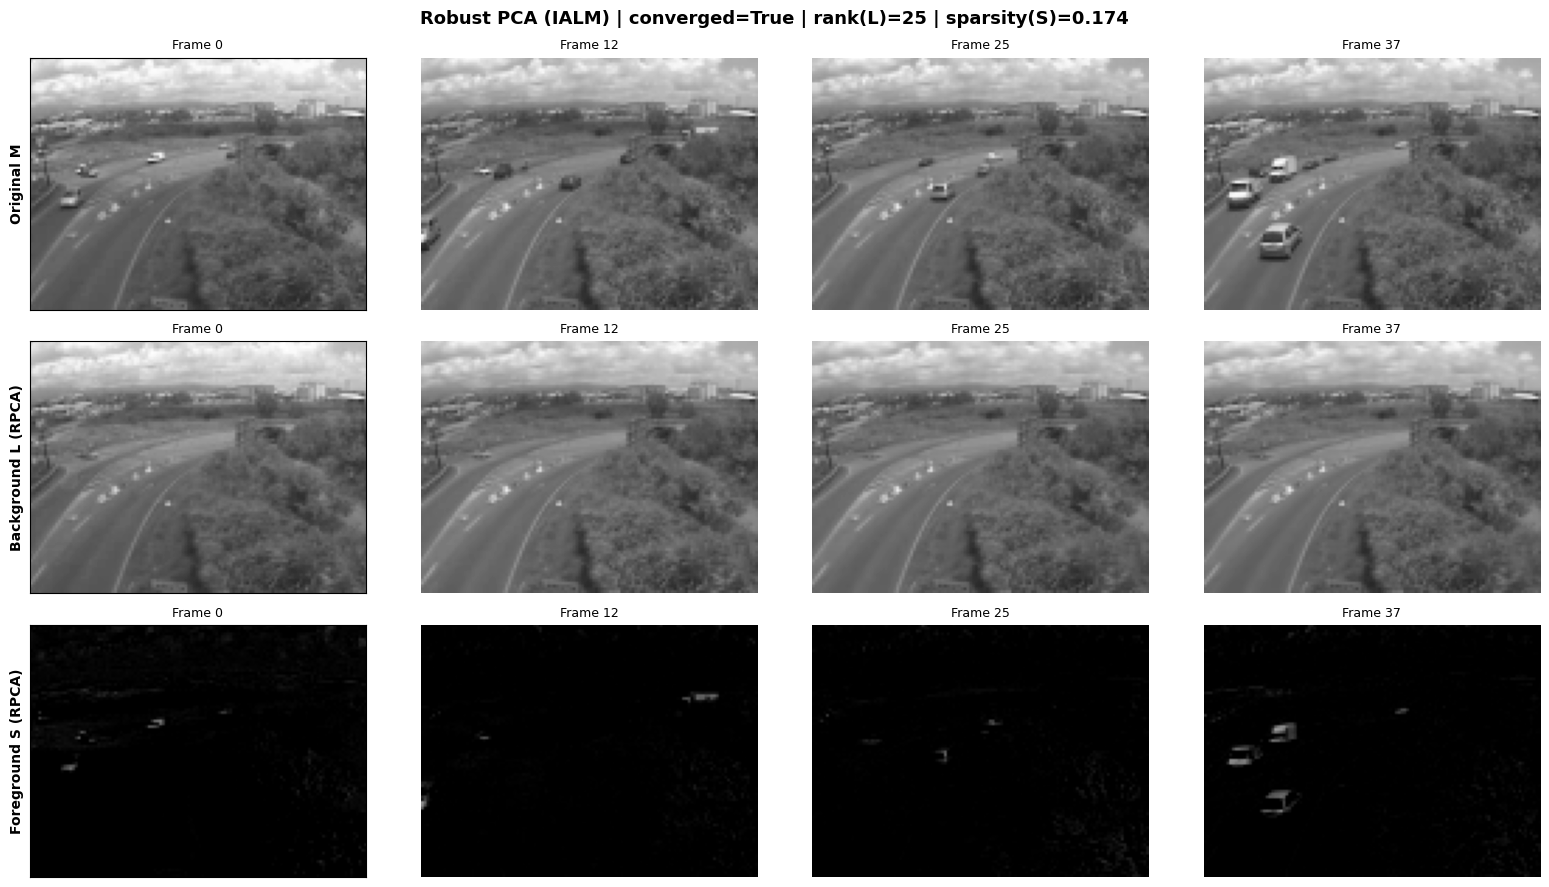

17:10:37 - INFO - RPCA result visualization saved: /home/isha/Desktop/AI_ML_2026/Projects/Robust_PCA_Video_Decomposition/outputs/rpca_result.png


In [ ]:
#Visualize RPCA results

#Select evenly spaced frames across the sequence
n_show = 4

frame_indices = np.linspace(0, M_real.shape[1] - 1, n_show,dtype=int)
visualize_rpca_result( rpca_real, M_real, CFG)


In [ ]:

#Result Summary

final_residual = diag_real.residuals[-1]
final_rank = diag_real.rank_L[-1]
final_sparsity = diag_real.sparsity_S[-1]

compression_ratio = final_rank / M_real.shape[1]

log.info("=" * 60)
log.info("GENERALIZATION RESULTS")
log.info("=" * 60)

log.info("Frames processed: %d", M_real.shape[1])
log.info("Matrix shape: %s", M_real.shape)
log.info("Final residual: %.3e", final_residual)
log.info("Estimated background rank: %d", final_rank)
log.info("Foreground sparsity: %.4f", final_sparsity)

log.info(
    "Compression ratio (rank / frames): %.4f",
    compression_ratio
)

log.info("=" * 60)



17:15:20 - INFO - ============================================================
17:15:20 - INFO - GENERALIZATION RESULTS
17:15:20 - INFO - ============================================================
17:15:20 - INFO - Frames processed: 50
17:15:20 - INFO - Matrix shape: (10800, 50)
17:15:20 - INFO - Final residual: 8.951e-08
17:15:20 - INFO - Estimated background rank: 25
17:15:20 - INFO - Foreground sparsity: 0.1741
17:15:20 - INFO - Compression ratio (rank / frames): 0.5000
17:15:20 - INFO - ============================================================


In [ ]:
#Restore the original configuration 
object.__setattr__(
    CFG,
    "matrix_filename",
    original_matrix_name
)

In [129]:
#Results interpretation

print(
f"""
RESULTS
============================================================

Frames processed:           {M_real.shape[1]}
Matrix shape:               {M_real.shape}

Final residual:             {final_residual:.3e}
Estimated background rank:  {final_rank}
Foreground sparsity:        {final_sparsity:.4f}

Compression ratio:          {compression_ratio:.4f}

============================================================

"""
)


RESULTS

Frames processed:           50
Matrix shape:               (10800, 50)

Final residual:             8.951e-08
Estimated background rank:  25
Foreground sparsity:        0.1741

Compression ratio:          0.5000






#### What These Numbers Mean

1. **Residual** 
- The residual measures how accurately RPCA reconstructed:

    M ≈ L + S

using the quantity:

    ||M - L - S||_F / ||M||_F

- The residual is extremely small, meaning the optimization
solver converged successfully and satisfied the decomposition
constraint very accurately.

- A tiny residual DOES NOT automatically mean the decomposition
is visually meaningful, but it suggests that optimization worked.


2. **Background Rank**

- The estimated rank indicates how many dominant singular
directions are needed to represent the background matrix L.

- Ideally, for static synthetic scenes: rank ≈ 1–5

- For actual scenes, the rank is often much higher due to: 
    - illumination variation
    - sensor noise
    - compression artifacts 
    - shadows 
    - subtle camera movement
    - auto exposure changes

- Rank value therefore does NOT automatically imply
RPCA failure.

- A higher rank simply means the background is not perfectly
stationary or perfectly low-dimensional.


3. **Foreground Sparsity**

- Foreground sparsity measures the fraction of nonzero entries
inside the sparse matrix S.

- RPCA assumes:
    - foreground occupies only a small subset of pixels
    - background dominates most of the image

Typical causes of increased sparsity: motion blur, shadows, noisy edges, compression artifacts, large moving objects

- A sparsity around 10–20% is often reasonable in real video.





4. Note: 
- For RPCA, VISUAL DECOMPOSITION QUALITY matters more than
the raw numerical rank estimate.

- If background in L looks stable, moving objects disappear from L, foreground appears isolated in S, then RPCA is functioning correctly EVEN IF the estimated rank is higher than expected.



5. **What failure actually looks like**
- RPCA is likely failing if you observe:
    - foreground ghosts inside L
    - background leaking into S
    - unstable/noisy decomposition
    - residuals failing to decrease
    - severe flickering artifacts

- These indicate the optimization or assumptions are breaking.



6. **Why real data is harder to work with**

- Synthetic benchmark datasets are designed to satisfy RPCA assumptions extremely well.

- Real-world videos violate those assumptions because:
    - backgrounds evolve over time
    - lighting changes continuously
    - sensors introduce noise
    - compression creates artifacts

- This naturally increases the effective rank of the background.



7. **Conclusion**
- If RPCA works better on synthetic data than on real-world
video, that is scientifically meaningful and expected.

- It demonstrates:
    - where low-rank assumptions hold
    - where they begin to break down
    - limitations of classical RPCA

